# ĐỒ ÁN MÔN HỌC: DỰ ĐOÁN NGUY CƠ BỎ HỌC VÀ KẾT QUẢ HỌC TẬP CỦA SINH VIÊN
---
**Mục tiêu:** Sử dụng các kỹ thuật Học máy để nhận diện sớm sinh viên có nguy cơ bỏ học (Dropout) tại một cơ sở giáo dục đại học, giúp nhà trường kịp thời đưa ra giải pháp can thiệp.

**Biến mục tiêu (Target):** Gồm 3 lớp: `Dropout` (Bỏ học), `Enrolled` (Đang học), `Graduate` (Tốt nghiệp).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.simplefilter('ignore')

## 1. Thu thập và Chuẩn bị dữ liệu

Nguồn gốc dữ liệu: Bộ dữ liệu này được thu thập thực tế từ Viện Bách khoa Portalegre (Polytechnic Institute of Portalegre) tại Bồ Đào Nha.

Hệ thống giáo dục Bồ Đào Nha: Tại các trường trung học và đại học ở Bồ Đào Nha, họ không dùng thang điểm 10 như Việt Nam, cũng không dùng thang điểm chữ (A, B, C, D, F) hay GPA 4.0 như Mỹ. Họ áp dụng thang điểm số từ 0 đến 20, trong đó:

20: Điểm tuyệt đối (Xuất sắc).

10: Điểm tối thiểu để vượt qua môn học (Qua môn).

Dưới 10: Trượt môn (Rớt).

In [2]:
data = pd.read_csv(r"D:\Documents\ML\Predict-students-dropout-and-academic-success\dataset.csv", sep = ';')
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Làm sạch dữ liệu

In [3]:
data.shape

(4424, 37)

In [4]:
# Checking for Null Values

data.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

*Không có giá trị nào bị thiếu trong tập dữ liệu.*

In [5]:
# Checking for duplicate values
duplicate = data[data.duplicated()]
print("Duplicate Rows :")
 
# Print the resultant Dataframe
duplicate

Duplicate Rows :


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target


*Không có hàng nào trùng lặp trong tập dữ liệu.*

In [6]:
data.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [7]:
# Thay tất cả các tên cột và thay thế khoảng trắng (' ') bằng dấu gạch dưới ('_')
data.columns = [x.replace(' ', '_') for x in data.columns]

In [8]:
data.head()

,Marital_status,Application_mode,Application_order,Course,Daytime/evening_attendance\t,Previous_qualification,Previous_qualification_(grade),Nacionality,Mother's_qualification,Father's_qualification,...,Curricular_units_2nd_sem_(credited),Curricular_units_2nd_sem_(enrolled),Curricular_units_2nd_sem_(evaluations),Curricular_units_2nd_sem_(approved),Curricular_units_2nd_sem_(grade),Curricular_units_2nd_sem_(without_evaluations),Unemployment_rate,Inflation_rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Phân tích khám phá dữ liệu

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital_status                                  4424 non-null   int64  
 1   Application_mode                                4424 non-null   int64  
 2   Application_order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening_attendance	                     4424 non-null   int64  
 5   Previous_qualification                          4424 non-null   int64  
 6   Previous_qualification_(grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's_qualification                          4424 non-null   int64  
 9   Father's_qualification                   

*Có 7 floating point numbers, 29 integers và chỉ có 1 object column.*

In [10]:
data['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

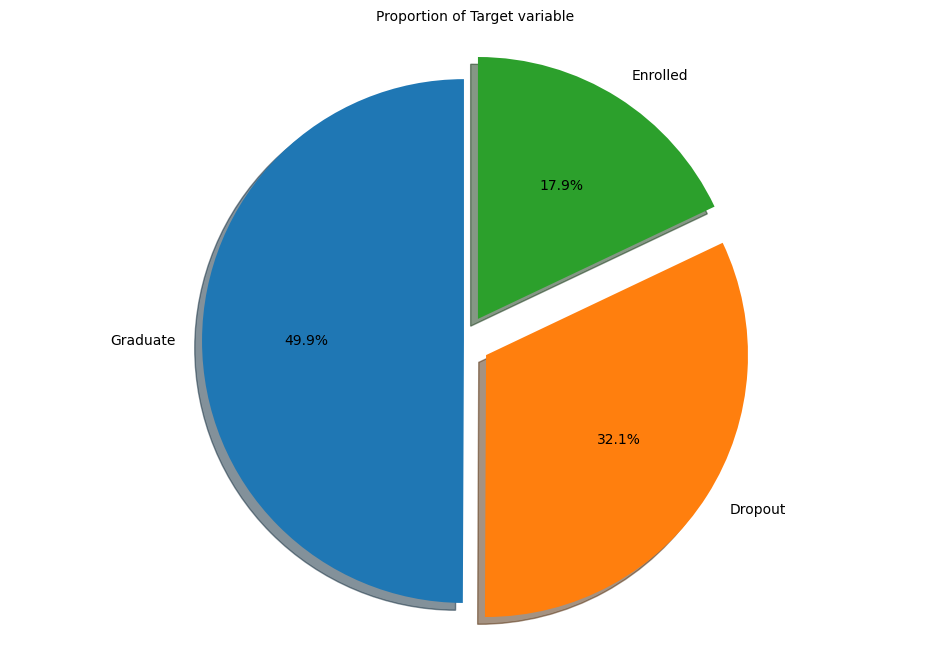

In [11]:
# Biểu đồ hình tròn hiển thị sự phân bố (phần trăm) của Target Variable

labels = 'Graduate', 'Dropout', 'Enrolled'
sizes = [data.Target[data['Target']=='Graduate'].count(), data.Target[data['Target']=='Dropout'].count(), data.Target[data['Target']=='Enrolled'].count()]
explode = (0, 0.1, 0.1)
fig1, ax1 = plt.subplots(figsize=(12, 8))
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')
plt.title("Proportion of Target variable", size = 10)
plt.show()

*Từ biểu đồ hình tròn ở trên, chúng ta có thể thấy rằng khoảng 49,9% sinh viên đã tốt nghiệp, 32,1% sinh viên bỏ học và 17,1% sinh viên đang theo học các khóa học khác, điều này cho thấy một nửa số sinh viên trong tổng số sinh viên đã tốt nghiệp.*

*Lượng bỏ học là 1/3, tỷ lệ này đủ lớn để mô hình học máy có thể học tốt đặc trưng của cả nhóm nghỉ học và nhóm tốt nghiệp mà không bị hiện tượng "học lệch".*

#### Hãy hình dung sự phân bố của các biến ngẫu nhiên liên tục.

In [12]:
# lọc riêng 7 biến số liên tục (như điểm số, tỷ lệ lạm phát, GDP, tỷ lệ thất nghiệp,...)

data_num = data.select_dtypes(include=['float64'])
data_num

,Previous_qualification_(grade),Admission_grade,Curricular_units_1st_sem_(grade),Curricular_units_2nd_sem_(grade),Unemployment_rate,Inflation_rate,GDP
0,122.0,127.3,0.000000,0.000000,10.8,1.4,1.74
1,160.0,142.5,14.000000,13.666667,13.9,-0.3,0.79
2,122.0,124.8,0.000000,0.000000,10.8,1.4,1.74
3,122.0,119.6,13.428571,12.400000,9.4,-0.8,-3.12
4,100.0,141.5,12.333333,13.000000,13.9,-0.3,0.79
...,...,...,...,...,...,...,...
4419,125.0,122.2,13.600000,12.666667,15.5,2.8,-4.06
4420,120.0,119.0,12.000000,11.000000,11.1,0.6,2.02
4421,154.0,149.5,14.912500,13.500000,13.9,-0.3,0.79
4422,180.0,153.8,13.800000,12.000000,9.4,-0.8,-3.12


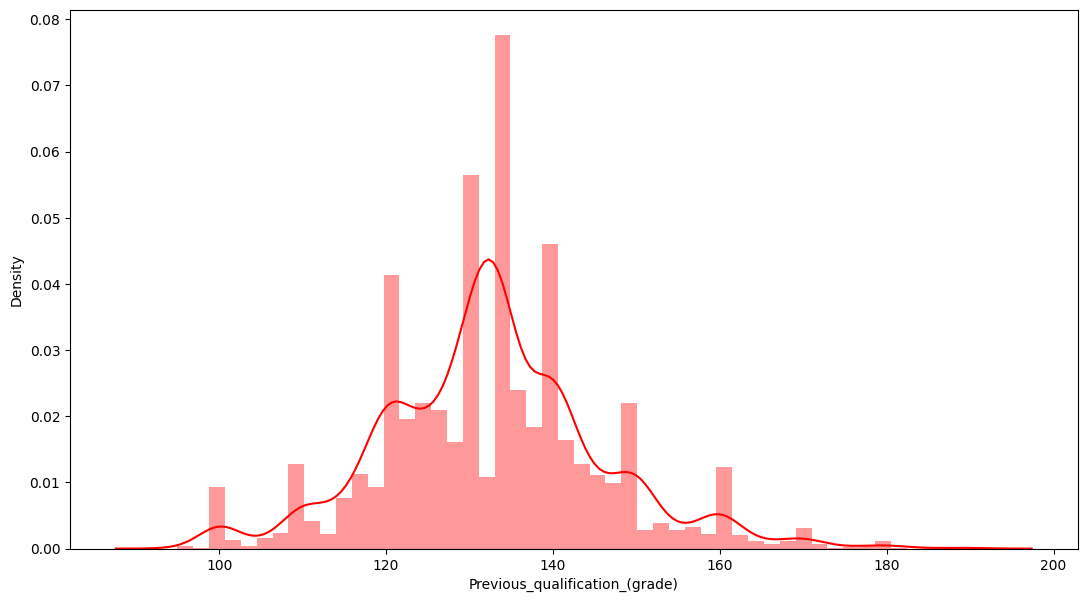

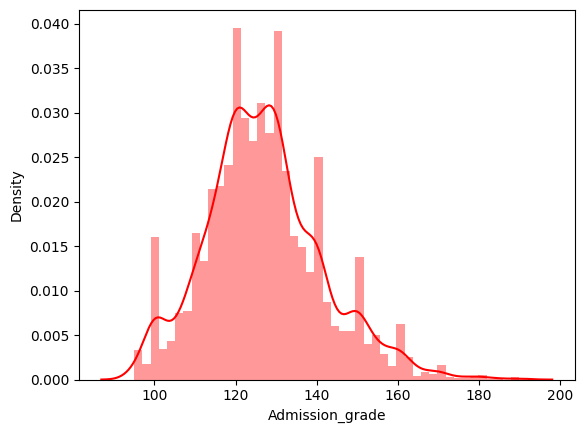

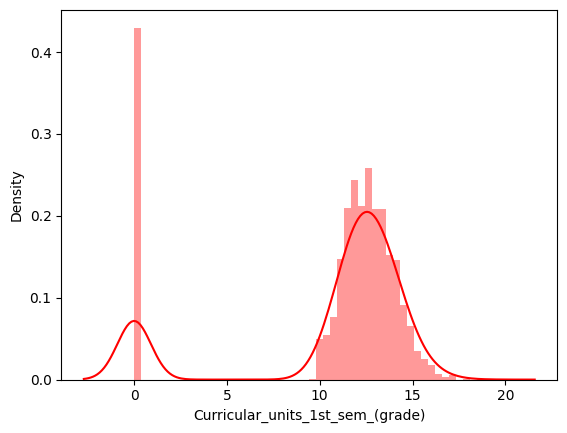

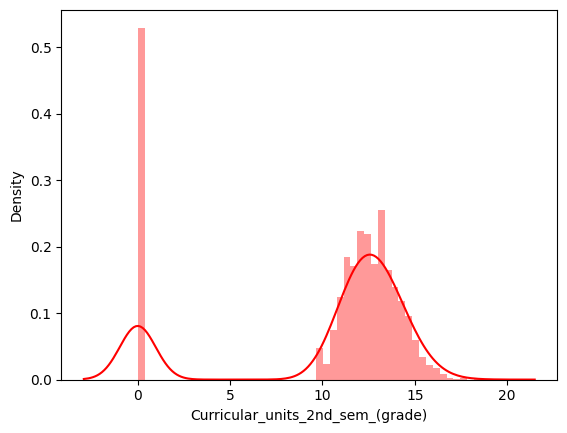

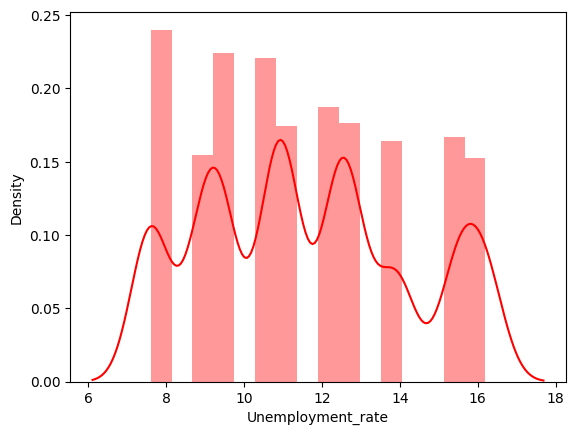

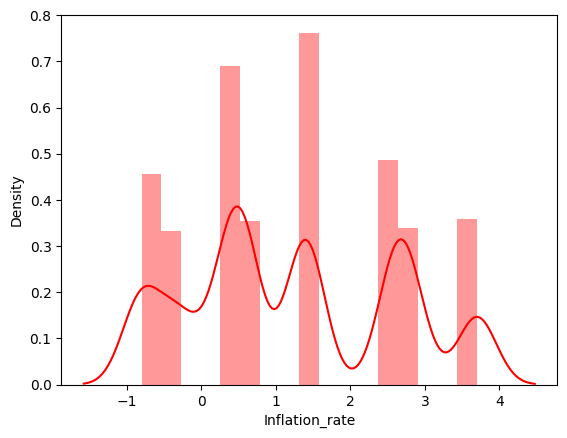

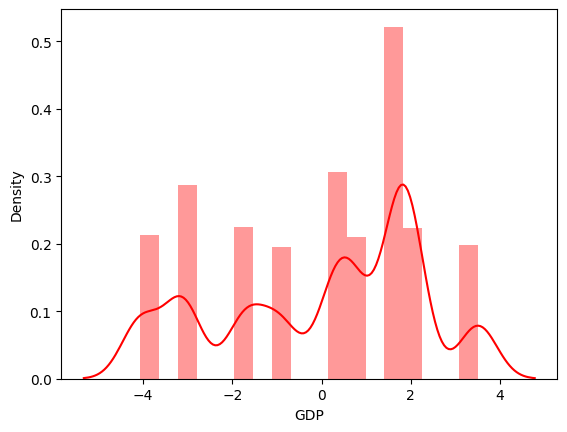

In [13]:
# Distribution Plot (Biểu đồ phân phối tần suất)
plt.figure(figsize = (13, 7))

for i in data_num.columns:
    sns.distplot(data[i], color = 'red')
    plt.show()

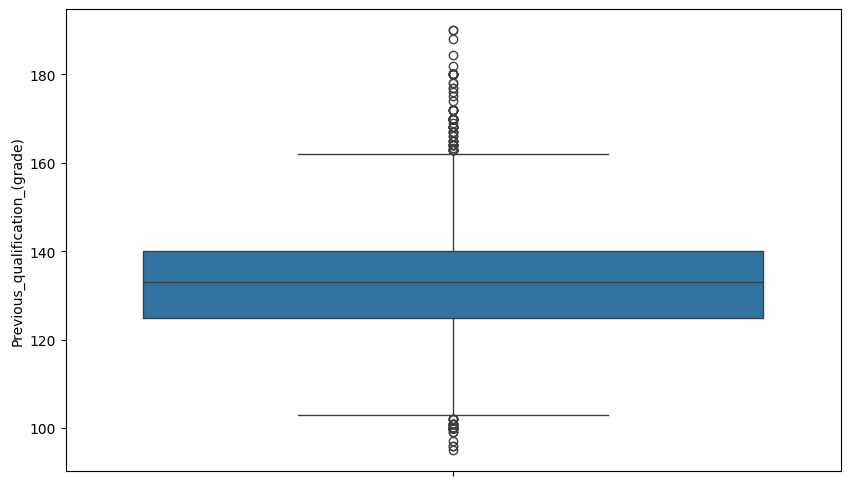

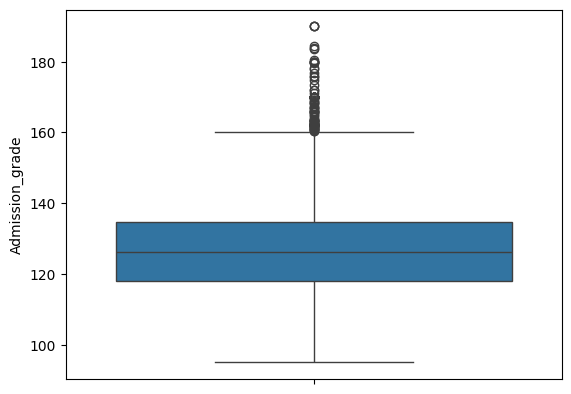

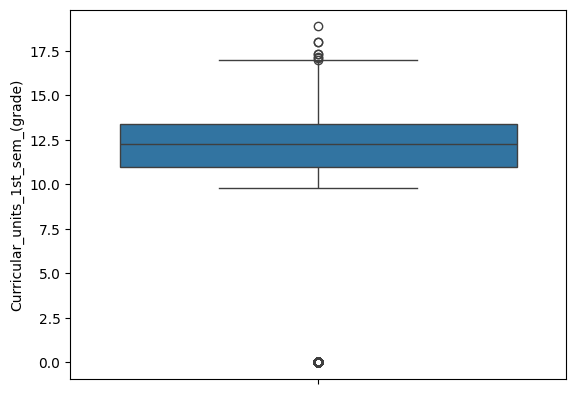

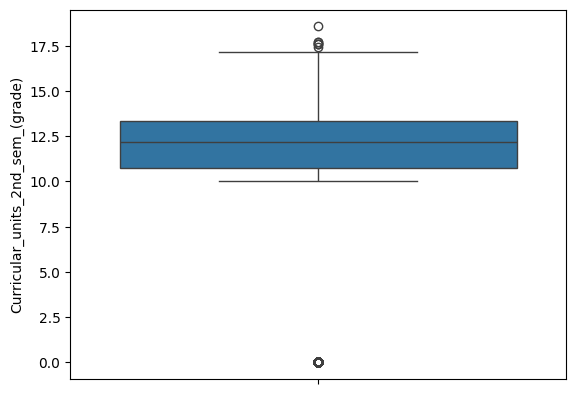

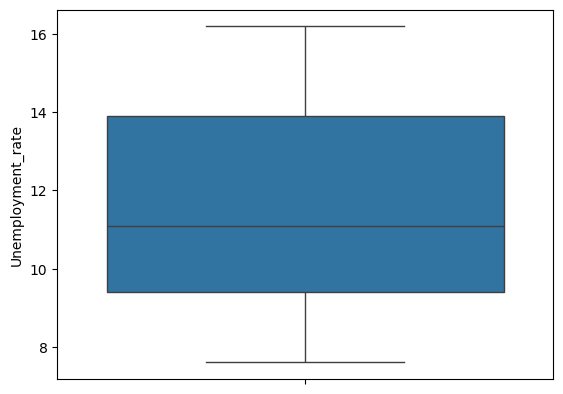

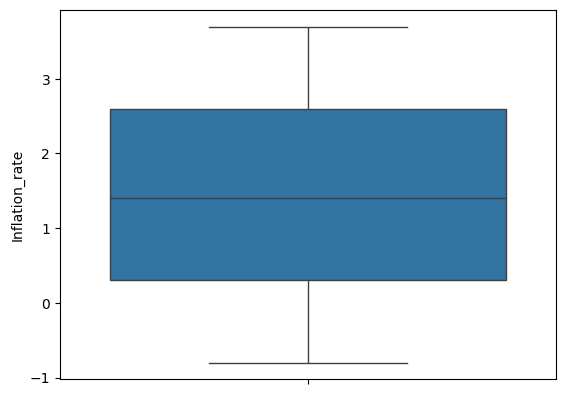

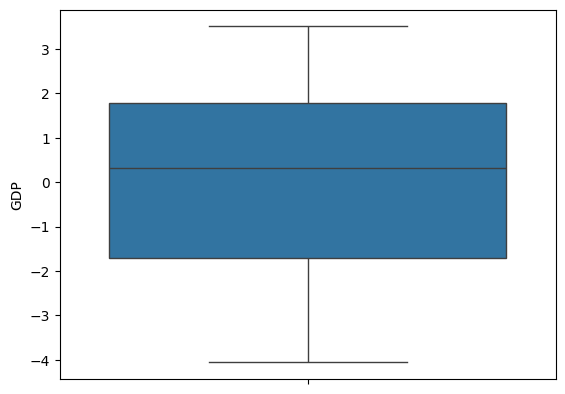

In [14]:
# BoxPlot (Biểu đồ hộp)
plt.figure(figsize = (10, 6))

for i in data_num.columns:
    sns.boxplot(data[i])
    plt.show()

*Từ các biểu đồ trên, chúng ta có thể thấy rằng hầu hết các chỉ số đều có giá trị ngoại lệ, ngoại trừ tỷ lệ thất nghiệp, tỷ lệ lạm phát và GDP.*

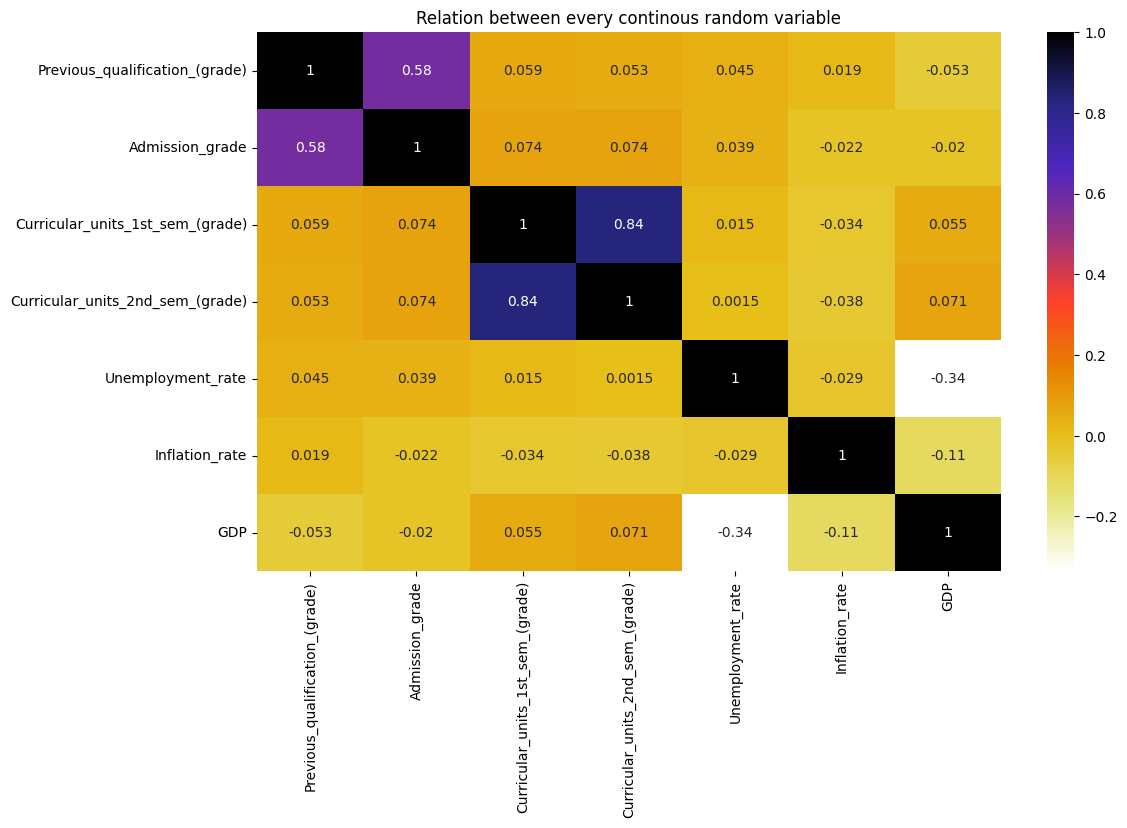

In [15]:
# Hiển thị mối tương quan giữa các biến số định lượng bằng biểu đồ nhiệt.

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 7))
cor = data_num.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.title('Relation between every continous random variable')
plt.show()

*Từ biểu đồ trên, ta có thể thấy rằng Curricular_units_1st_sem_(grade) & Curricular_units_2nd_sem_(grade) có mối tương quan mạnh với nhau, trong khi Previous_qualification_(grade) & Admission_grade có mối quan hệ trung bình, còn GDP, tỷ lệ lạm phát và tỷ lệ thất nghiệp lại có mối quan hệ nghịch với nhau.*




#### Bây giờ chúng ta hãy hình dung các biến ngẫu nhiên rời rạc (phân loại).

In [16]:
# Lấy danh sách biến ngẫu nhiên liên tục
num_data = [cname for cname in data.columns if data[cname].dtypes in ['float64']]
num_data

['Previous_qualification_(grade)',
 'Admission_grade',
 'Curricular_units_1st_sem_(grade)',
 'Curricular_units_2nd_sem_(grade)',
 'Unemployment_rate',
 'Inflation_rate',
 'GDP']

In [17]:
# Lấy danh sách các biến ngẫu nhiên rời rạc
cat_cols = data._get_numeric_data().columns
cat_cols

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime/evening_attendance\t', 'Previous_qualification',
       'Previous_qualification_(grade)', 'Nacionality',
       'Mother's_qualification', 'Father's_qualification',
       'Mother's_occupation', 'Father's_occupation', 'Admission_grade',
       'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_(credited)',
       'Curricular_units_1st_sem_(enrolled)',
       'Curricular_units_1st_sem_(evaluations)',
       'Curricular_units_1st_sem_(approved)',
       'Curricular_units_1st_sem_(grade)',
       'Curricular_units_1st_sem_(without_evaluations)',
       'Curricular_units_2nd_sem_(credited)',
       'Curricular_units_2nd_sem_(enrolled)',
       'Curricular_units_2nd_sem_(evaluations)',
       'Curricular_units_2nd_sem_(approved)',
       'Curricular_units_2nd

In [18]:
# Phân tách các biến ngẫu nhiên rời rạc và liên tục.
cols = list(set(cat_cols) - set(num_data))
cols

['Marital_status',
 "Mother's_occupation",
 'Curricular_units_2nd_sem_(without_evaluations)',
 'Nacionality',
 'Curricular_units_1st_sem_(evaluations)',
 'Previous_qualification',
 'Curricular_units_1st_sem_(credited)',
 'Curricular_units_2nd_sem_(approved)',
 'Curricular_units_2nd_sem_(evaluations)',
 "Father's_occupation",
 'Application_mode',
 'Curricular_units_2nd_sem_(enrolled)',
 'Curricular_units_1st_sem_(without_evaluations)',
 'Displaced',
 'Daytime/evening_attendance\t',
 'Curricular_units_1st_sem_(approved)',
 'Course',
 "Mother's_qualification",
 'Educational_special_needs',
 'Tuition_fees_up_to_date',
 'International',
 "Father's_qualification",
 'Curricular_units_2nd_sem_(credited)',
 'Gender',
 'Application_order',
 'Age_at_enrollment',
 'Curricular_units_1st_sem_(enrolled)',
 'Debtor',
 'Scholarship_holder']

In [19]:
len(cols)

29

In [20]:
data.head()

,Marital_status,Application_mode,Application_order,Course,Daytime/evening_attendance\t,Previous_qualification,Previous_qualification_(grade),Nacionality,Mother's_qualification,Father's_qualification,...,Curricular_units_2nd_sem_(credited),Curricular_units_2nd_sem_(enrolled),Curricular_units_2nd_sem_(evaluations),Curricular_units_2nd_sem_(approved),Curricular_units_2nd_sem_(grade),Curricular_units_2nd_sem_(without_evaluations),Unemployment_rate,Inflation_rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Bây giờ chúng ta hãy trực quan hóa dữ liệu phân loại

### Phân tích đơn biến và đa biến

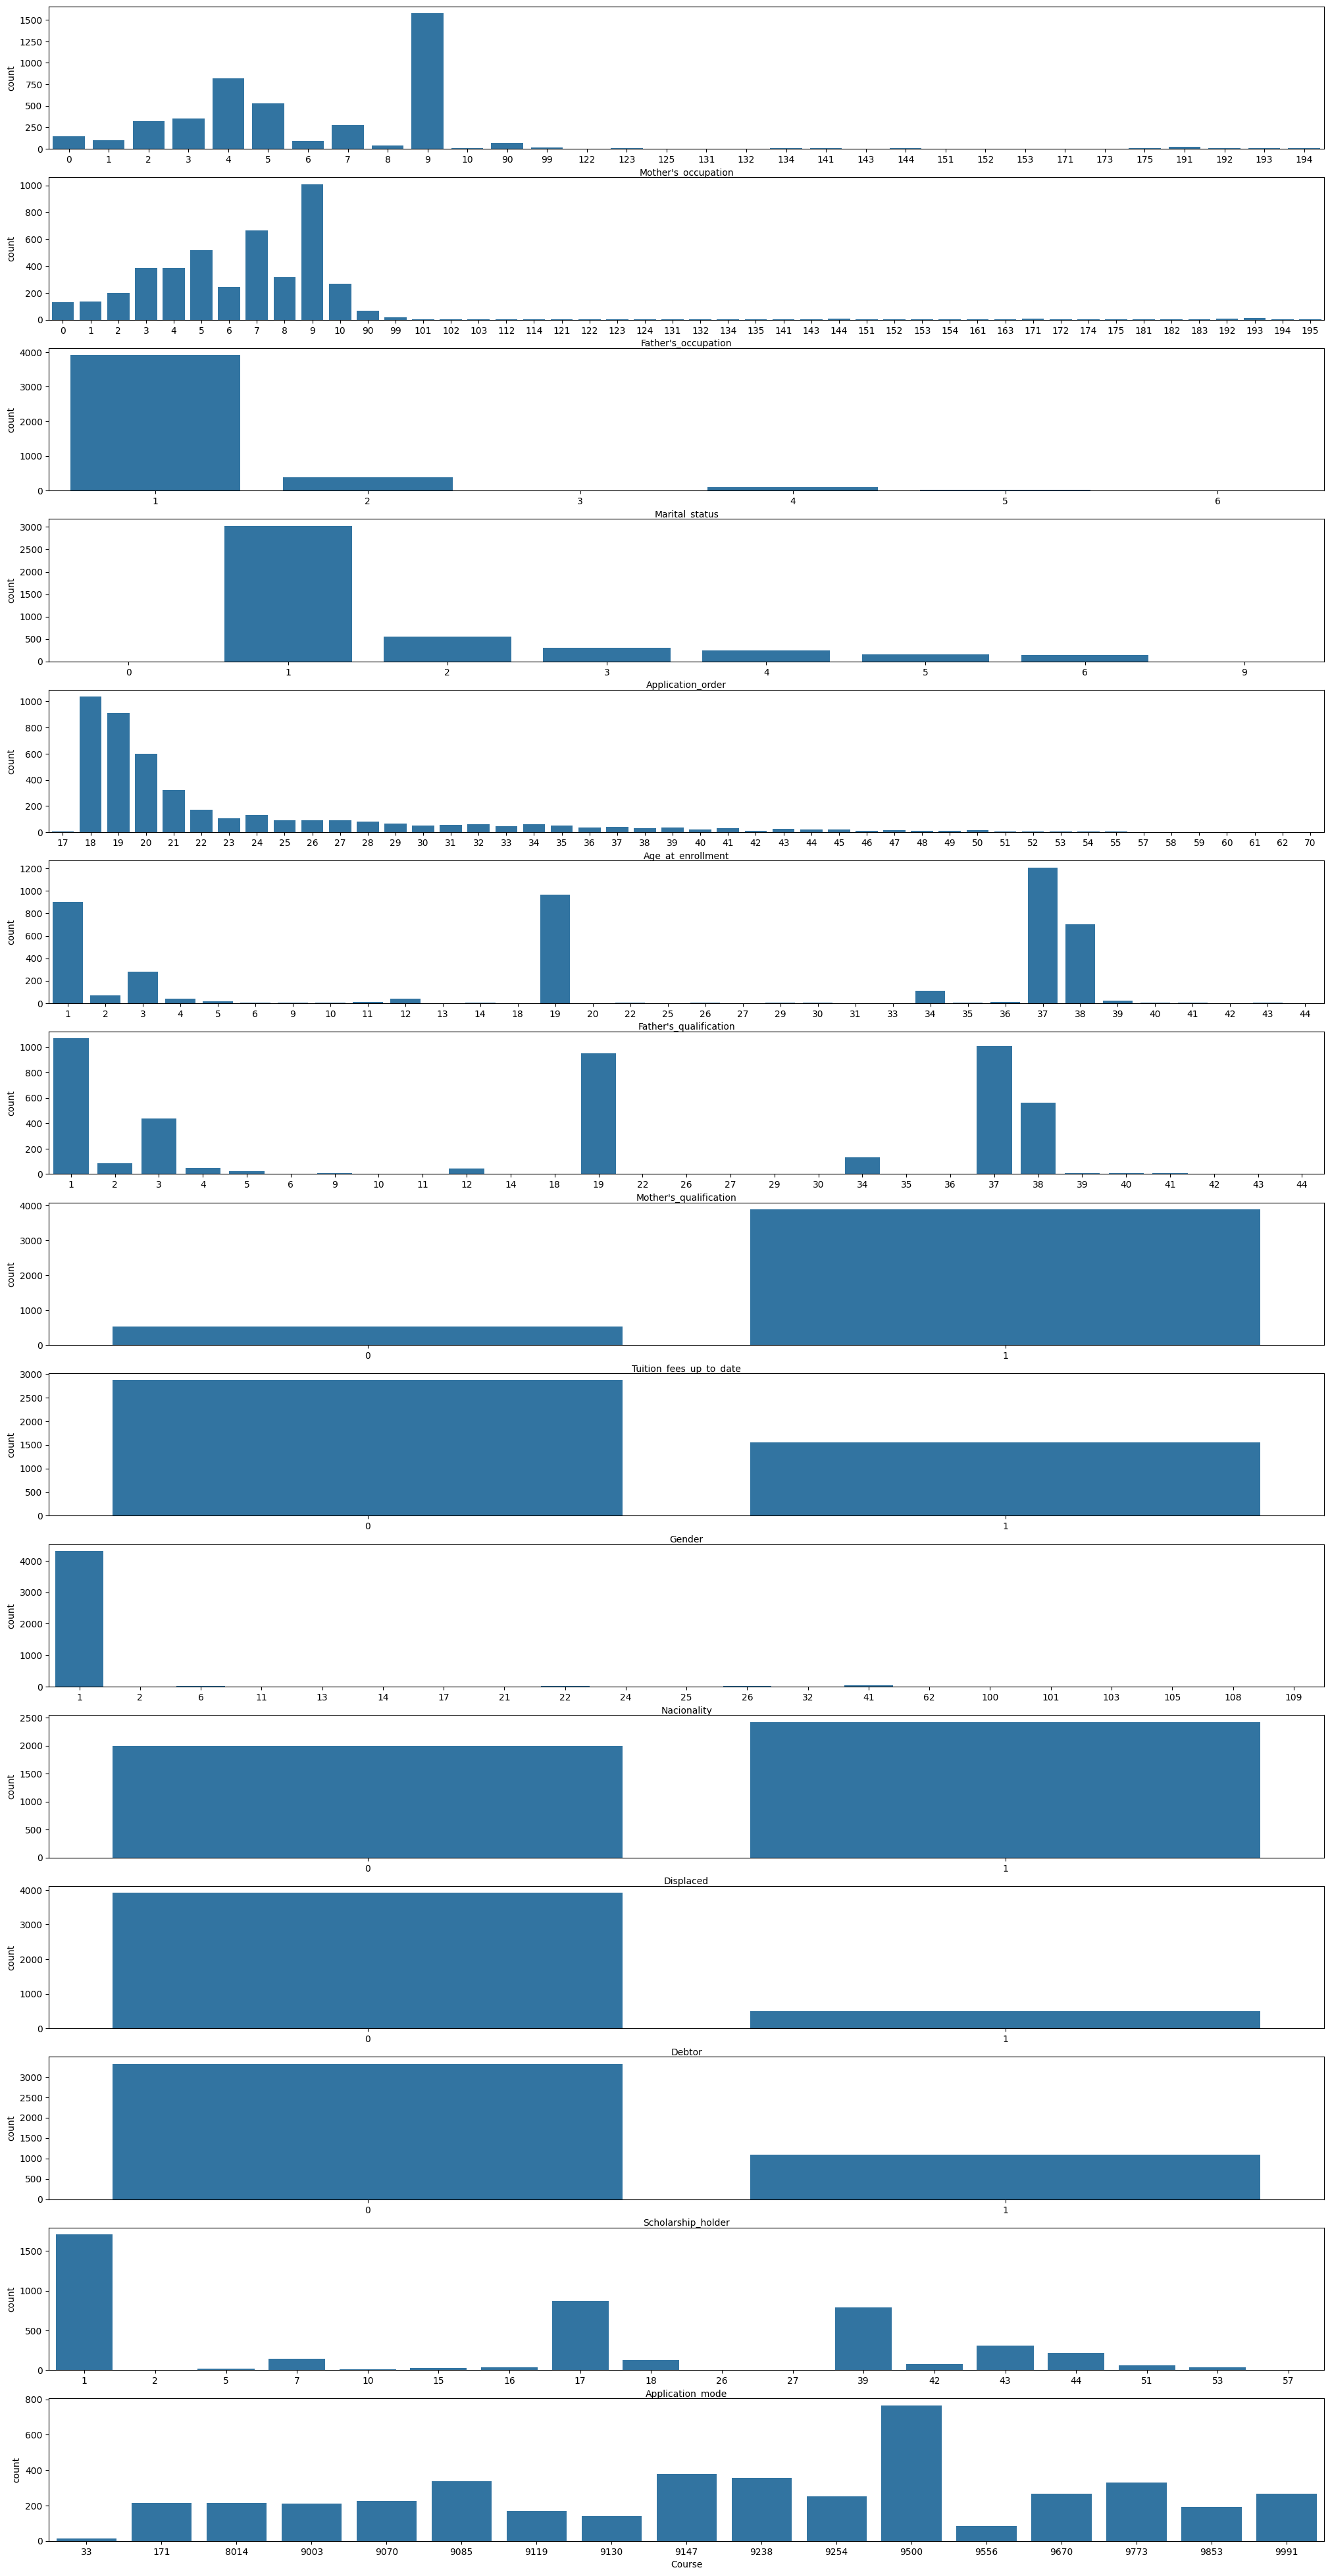

In [21]:
fig, ax = plt.subplots(nrows=15, ncols=1, figsize=(25, 50))

cols_ = ["Mother's_occupation",
 "Father's_occupation",
 'Marital_status',
 'Application_order',
 'Age_at_enrollment',
 "Father's_qualification",
 "Mother's_qualification",
 'Tuition_fees_up_to_date',
 'Gender',
  "Nacionality",
 'Displaced',
 'Debtor',
 "Scholarship_holder",
 'Application_mode',
 'Course']

for ind, col in enumerate(cols_):
    sns.countplot(x=col, data=data, ax=ax[ind])

## Thông tin chi tiết

1. Đa số các bà mẹ là lao động phổ thông, tiếp theo là nhân viên hành chính, nhân viên an toàn và người bán hàng.

2. Đa số các ông bố của học sinh là lao động phổ thông, tiếp theo là công nhân lành nghề trong ngành công nghiệp, nhân viên an toàn, nhân viên bảo vệ và người bán hàng.

3. Hơn 90% học sinh trong bộ dữ liệu đã cho là độc thân.

4. Đa số học sinh đăng ký học ở độ tuổi 18, 19 và 20.
5. Đa số phụ huynh có trình độ học vấn rất cơ bản, từ lớp 5 đến lớp 12.

6. Hơn 90% học sinh đóng học phí đúng hạn.

7. Trong nhóm học sinh này, hơn 60% là nữ.

8. Hầu hết học sinh trong nhóm này đều là người Bồ Đào Nha.

9. Đa số học sinh trong nhóm này không phải là người nhận học bổng.

10. Đa số học sinh trong nhóm này tham gia giai đoạn 1 của quy trình đăng ký, tiếp theo là giai đoạn 2.

11. Số lượng sinh viên đăng ký học ngành Điều dưỡng nhiều nhất, tiếp theo là các ngành Quản lý, Dịch vụ xã hội, Báo chí và Truyền thông.

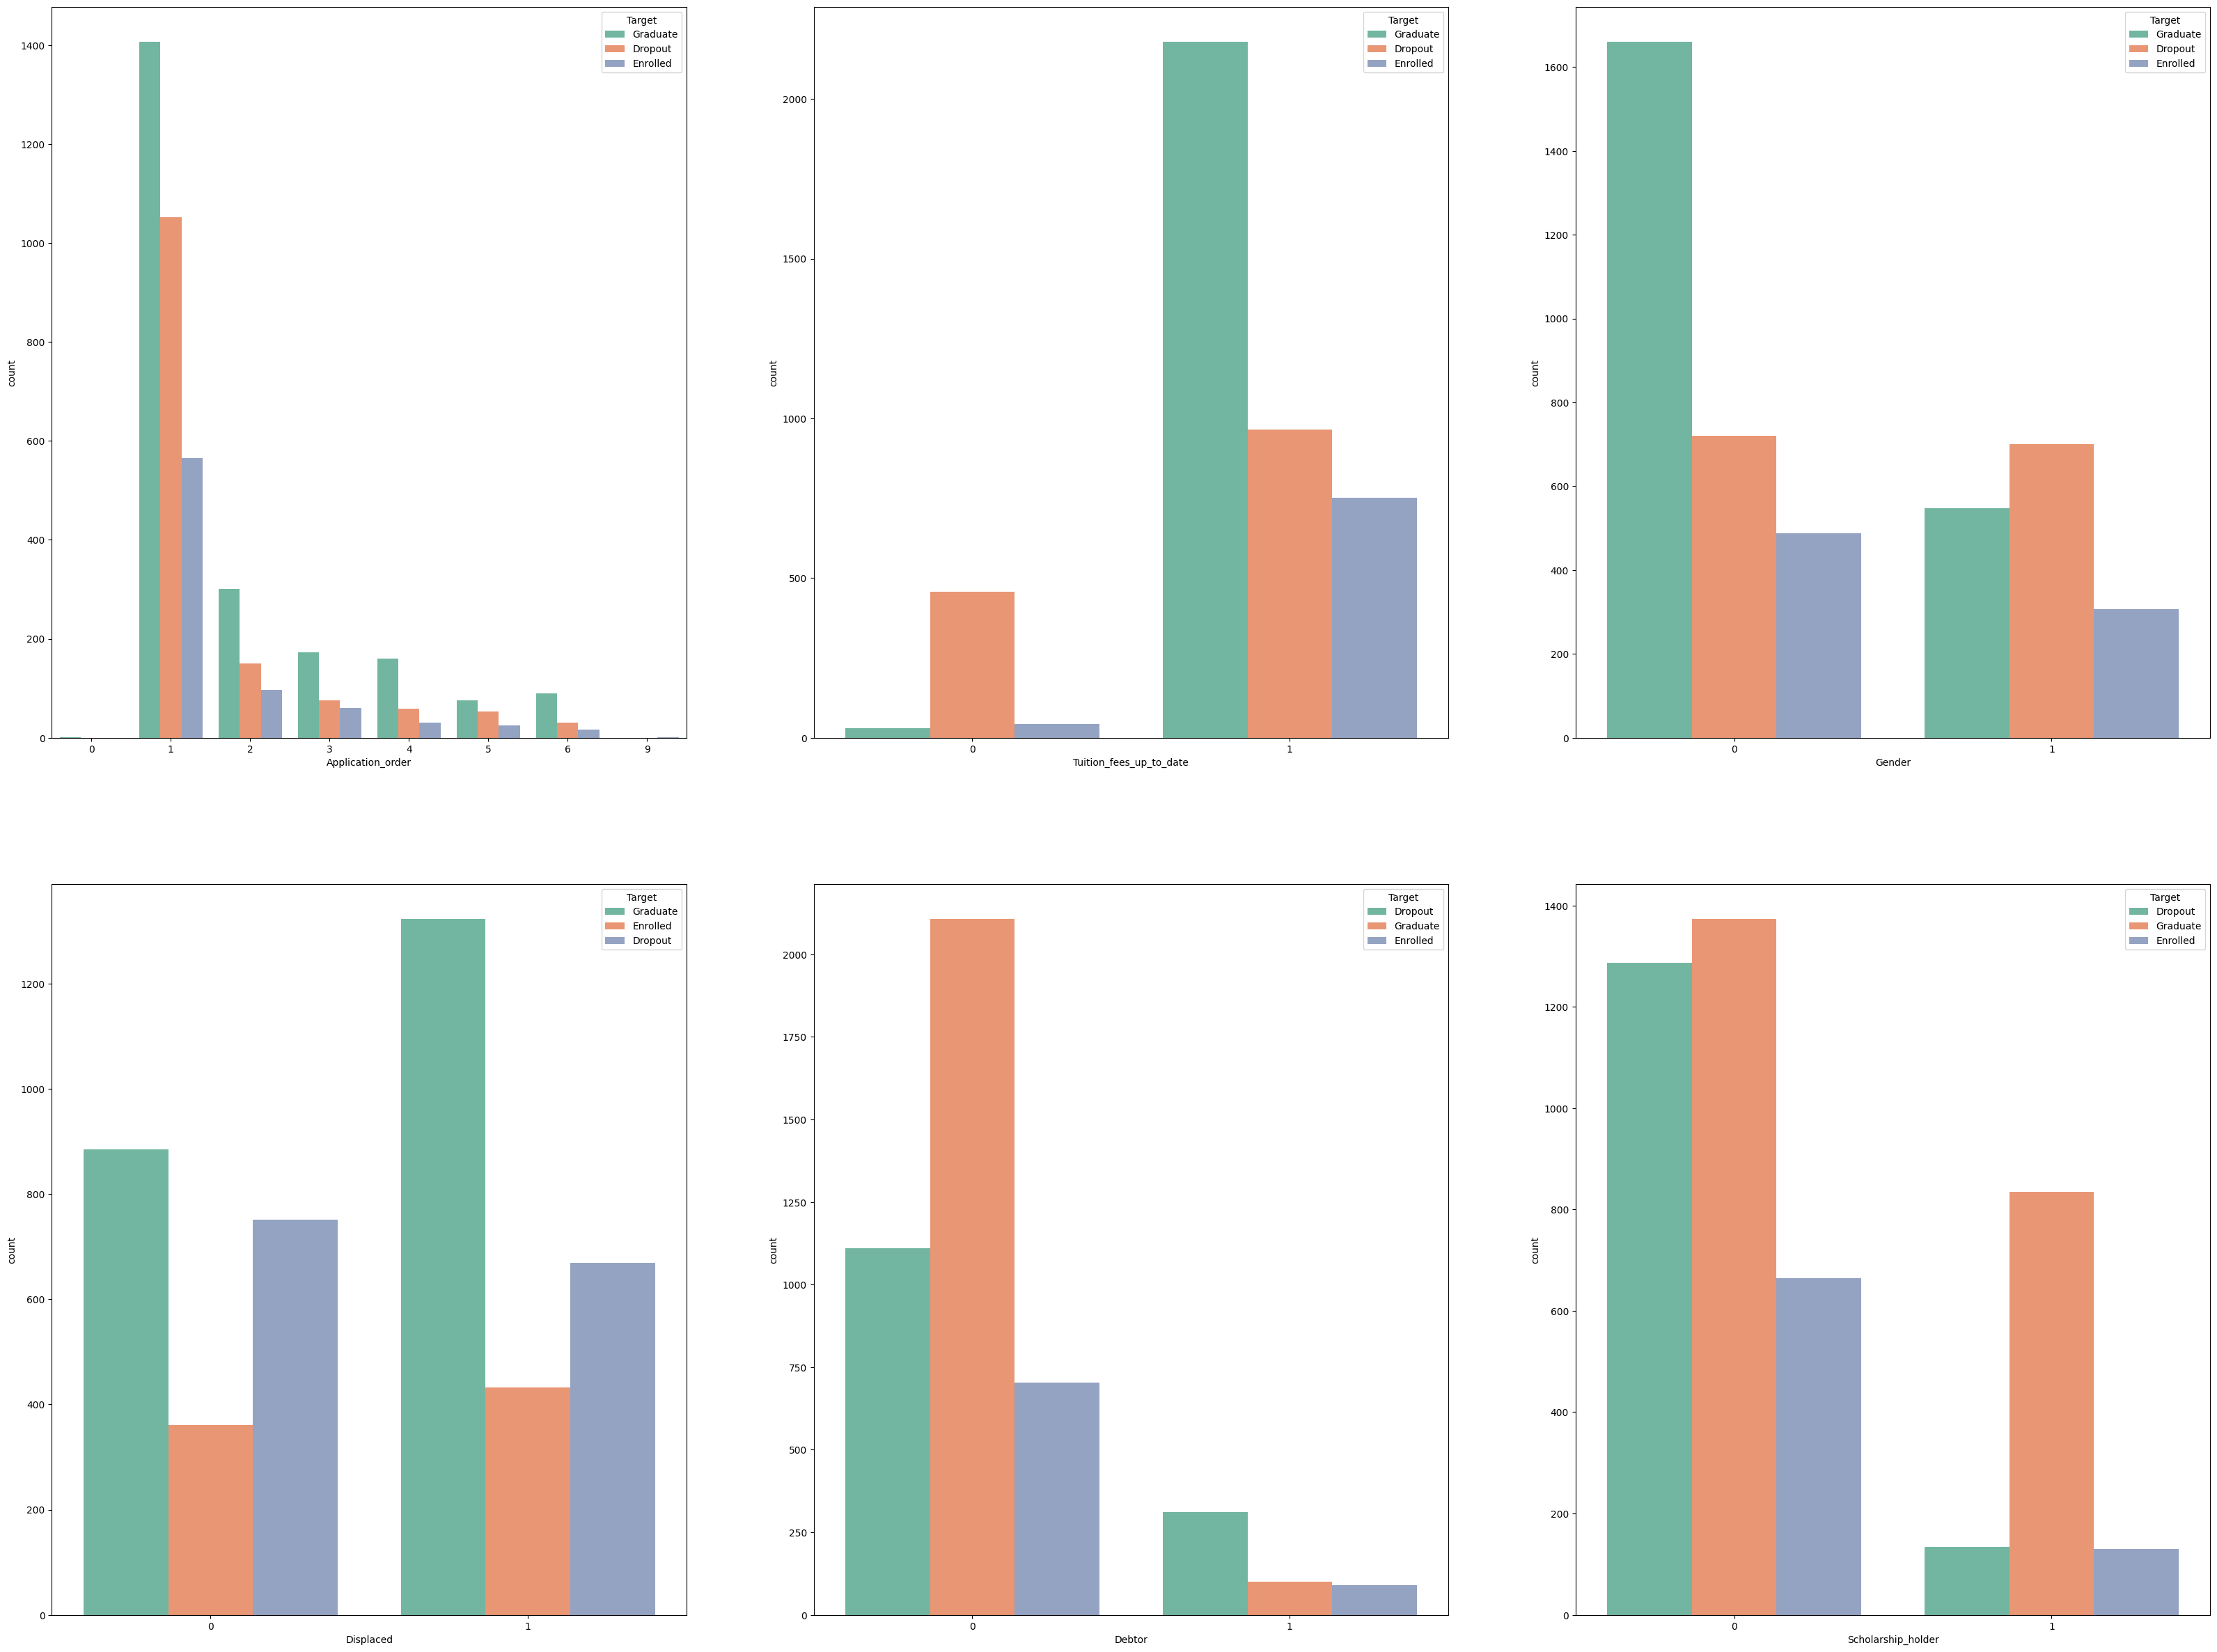

In [22]:
# Hãy cùng phân tích tác động của từng biến số nêu trên lên Target Variable

fig, ax = plt.subplots(2, 3, figsize=(40, 30))

sns.countplot(x='Application_order', hue='Target', data=data, palette='Set2', ax=ax[0][0])
sns.countplot(x='Tuition_fees_up_to_date', hue='Target', data=data, palette='Set2', ax=ax[0][1])
sns.countplot(x='Gender', hue='Target', data=data, palette='Set2', ax=ax[0][2])
sns.countplot(x='Displaced', hue='Target', data=data, palette='Set2', ax=ax[1][0])
sns.countplot(x='Debtor', hue='Target', data=data, palette='Set2', ax=ax[1][1])
sns.countplot(x='Scholarship_holder', hue='Target', data=data, palette='Set2', ax=ax[1][2])


plt.show()

## Nhận định

1. Chúng ta có thể thấy rằng những sinh viên không đóng học phí đúng hạn có nguy cơ bỏ học cao hơn.

2. Tỷ lệ bỏ học cao nhất là nam sinh.

3. Những sinh viên đang mắc nợ có nguy cơ bỏ học cao hơn.

## Feature Engineering/ Feature Selection

### Xử lý dữ liệu phân loại

In [23]:
# Chuyển đổi Target variable thành dữ liệu số

from sklearn.preprocessing import LabelEncoder
le =LabelEncoder() 

data['Target'] = le.fit_transform(data['Target'])

### Outlier Handling  (Xử lý dữ liệu ngoại lai)

In [24]:
data_num.columns

Index(['Previous_qualification_(grade)', 'Admission_grade',
       'Curricular_units_1st_sem_(grade)', 'Curricular_units_2nd_sem_(grade)',
       'Unemployment_rate', 'Inflation_rate', 'GDP'],
      dtype='object')

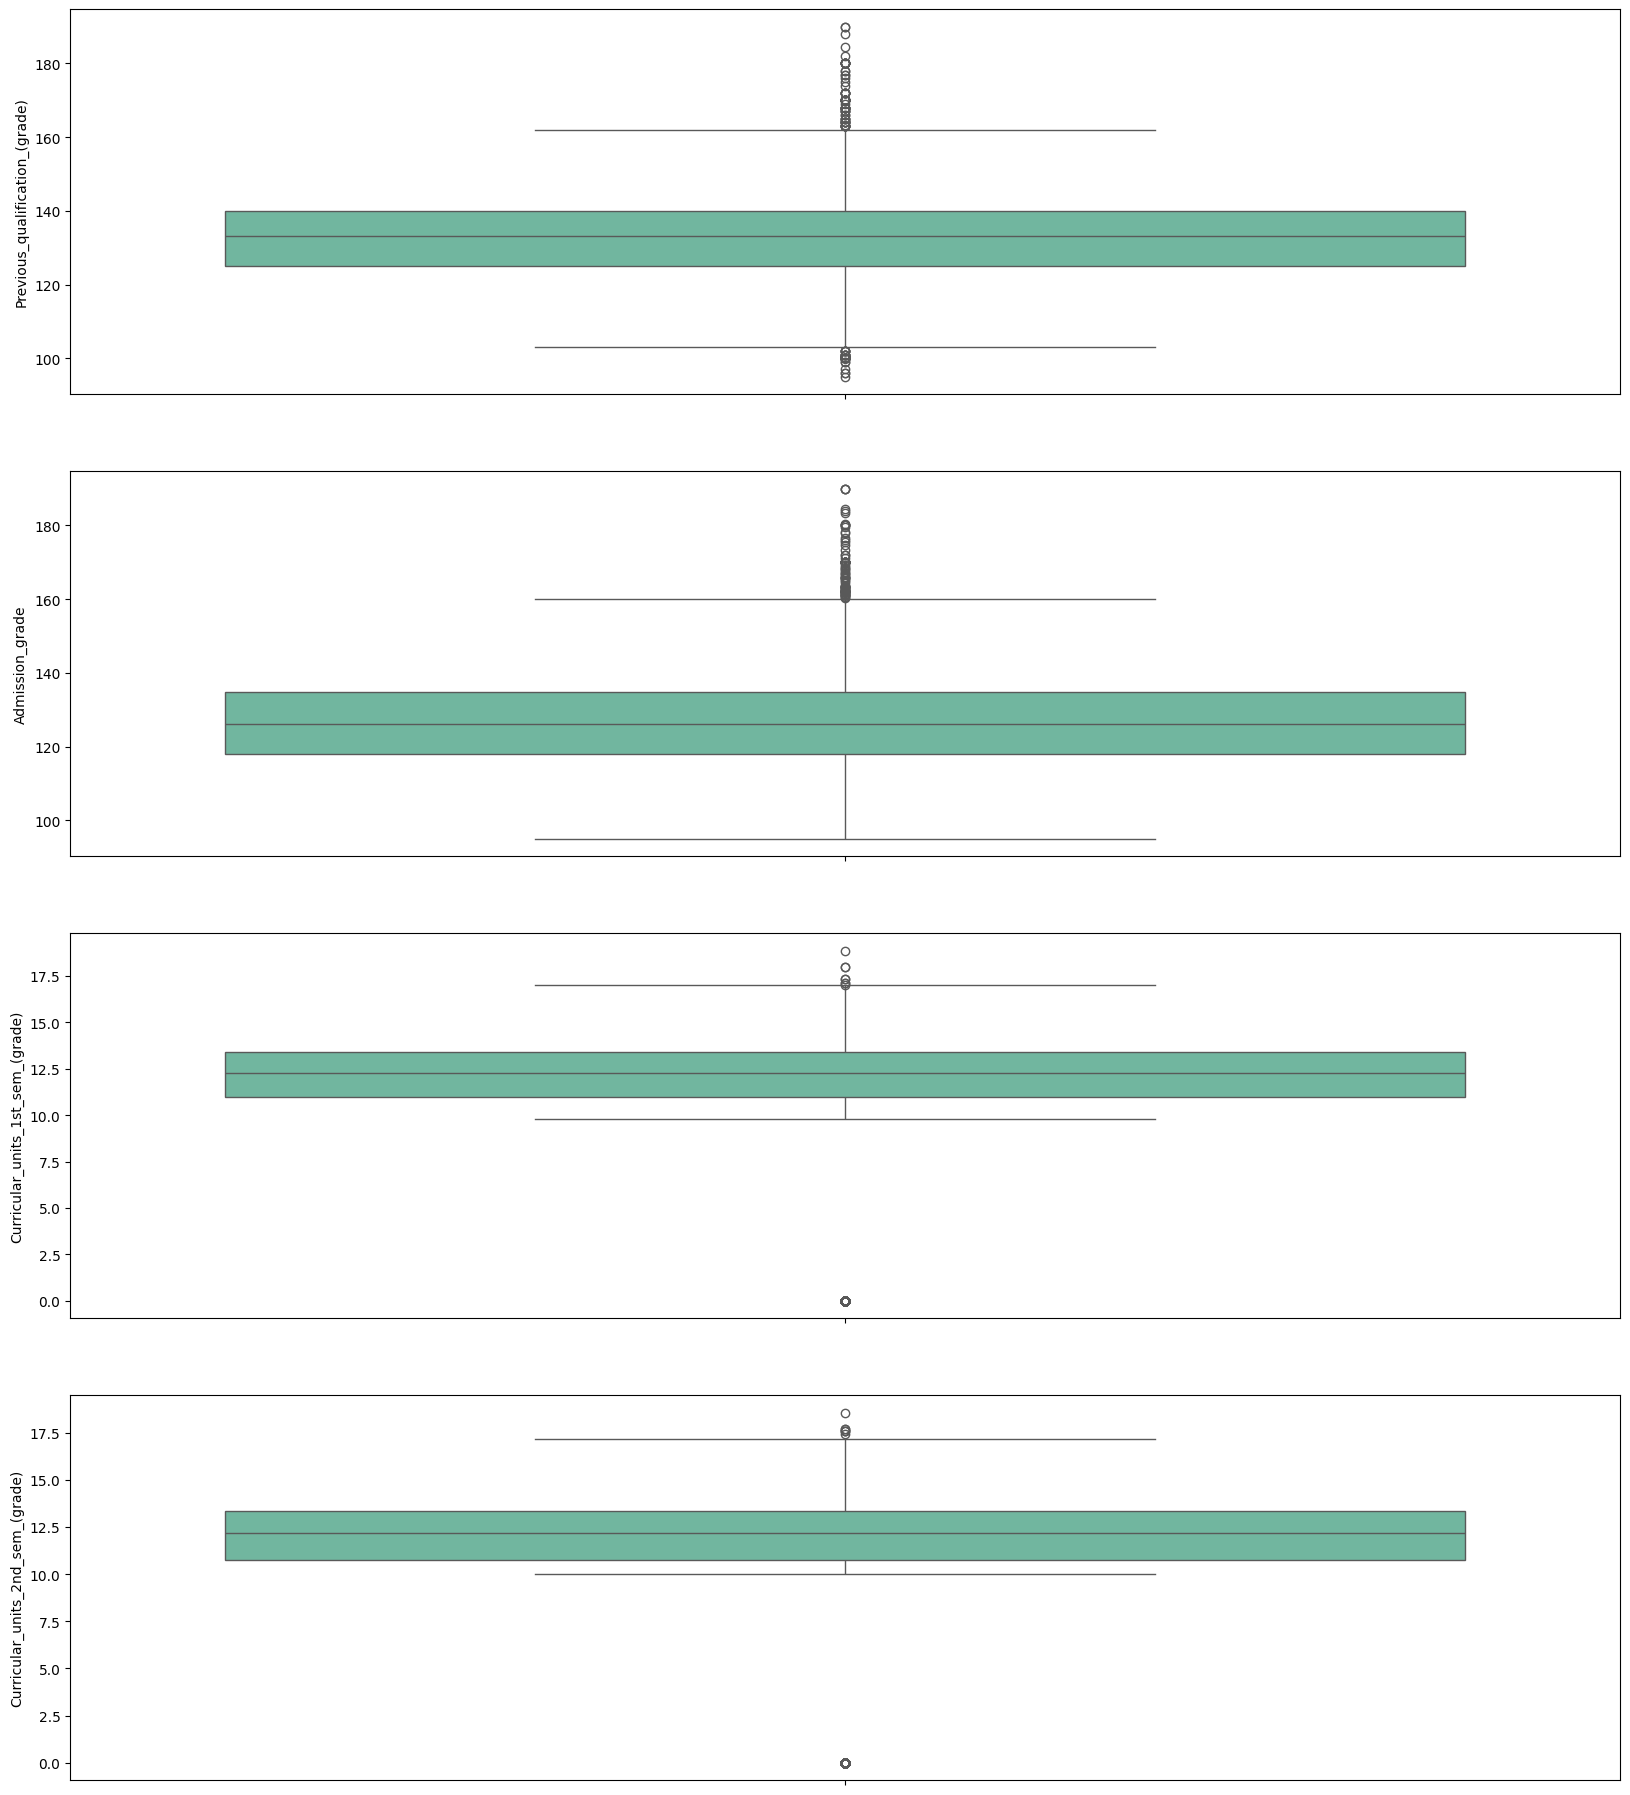

In [25]:
## Hiển thị biểu đồ hộp trước khi xử lý giá trị ngoại lệ.

fig, axs = plt.subplots(4,1, figsize = (20, 23))
plt1 = sns.boxplot(data['Previous_qualification_(grade)'], ax = axs[0], palette = 'BuGn')
plt1 = sns.boxplot(data['Admission_grade'], ax = axs[1], palette = 'BuGn')
plt1 = sns.boxplot(data['Curricular_units_1st_sem_(grade)'], ax = axs[2], palette = 'BuGn')
plt1 = sns.boxplot(data['Curricular_units_2nd_sem_(grade)'], ax = axs[3], palette = 'BuGn')

plt.show()

In [26]:
data[['Previous_qualification_(grade)', 'Admission_grade', 'Curricular_units_1st_sem_(grade)', 'Curricular_units_2nd_sem_(grade)']].describe()

,Previous_qualification_(grade),Admission_grade,Curricular_units_1st_sem_(grade),Curricular_units_2nd_sem_(grade)
count,4424.000000,4424.000000,4424.000000,4424.000000
mean,132.613314,126.978119,10.640822,10.230206
std,13.188332,14.482001,4.843663,5.210808
min,95.000000,95.000000,0.000000,0.000000
25%,125.000000,117.900000,11.000000,10.750000
50%,133.100000,126.100000,12.285714,12.200000
75%,140.000000,134.800000,13.400000,13.333333
max,190.000000,190.000000,18.875000,18.571429


## Phương pháp IQR cực đoan

*Bước 1 - Tính Khoảng tứ phân vị:*

*IQR = Q_3 - Q_1
(Trong đó Q_1 là mốc 25% và Q_3 là mốc 75% lấy từ hàm .describe() trước đó).*

*Bước 2 - Thiết lập hàng rào an toàn để lọc dữ liệu:*

Biên dưới = Q_1 - 3 x IQR ;

Biên trên = Q_3 + 3 x IQR

In [27]:
# Xử lý dữ liệu ngoại lai cho Previous_qualification_(grade)

Q1 = data['Previous_qualification_(grade)'].quantile(0.25)
Q3 = data['Previous_qualification_(grade)'].quantile(0.75)

IQR = Q3 - Q1
data = data[(data['Previous_qualification_(grade)'] >= Q1 - 3*IQR) & (data['Previous_qualification_(grade)'] <= Q3 + 3*IQR)]

In [28]:
# Xử lý dữ liệu ngoại lai cho Admission_grade

Q1 = data['Admission_grade'].quantile(0.25)
Q3 = data['Admission_grade'].quantile(0.75)

IQR = Q3 - Q1
data = data[(data['Admission_grade'] >= Q1 - 3*IQR) & (data['Admission_grade'] <= Q3 + 3*IQR)]

In [29]:
# Xử lý dữ liệu ngoại lai cho Curricular_units_1st_sem_(grade)'

Q1 = data['Curricular_units_1st_sem_(grade)'].quantile(0.25)
Q3 = data['Curricular_units_1st_sem_(grade)'].quantile(0.75)

IQR = Q3 - Q1
data = data[(data['Curricular_units_1st_sem_(grade)'] >= Q1 - 3*IQR) & (data['Curricular_units_1st_sem_(grade)'] <= Q3 + 3*IQR)]

In [30]:
# Xử lý dữ liệu ngoại lai cho Curricular_units_2nd_sem_(grade)'

Q1 = data['Curricular_units_2nd_sem_(grade)'].quantile(0.25)
Q3 = data['Curricular_units_2nd_sem_(grade)'].quantile(0.75)

IQR = Q3 - Q1
data = data[(data['Curricular_units_2nd_sem_(grade)'] >= Q1 - 3*IQR) & (data['Curricular_units_2nd_sem_(grade)'] <= Q3 + 3*IQR)]

In [31]:
data[['Previous_qualification_(grade)', 'Admission_grade', 'Curricular_units_1st_sem_(grade)', 'Curricular_units_2nd_sem_(grade)']].describe()

,Previous_qualification_(grade),Admission_grade,Curricular_units_1st_sem_(grade),Curricular_units_2nd_sem_(grade)
count,3509.000000,3509.000000,3509.000000,3509.000000
mean,132.599231,127.084981,12.749182,12.745582
std,12.977814,13.769560,1.328290,1.372024
min,95.000000,95.000000,10.000000,10.000000
25%,124.000000,118.400000,11.800000,11.750000
50%,133.000000,126.300000,12.666667,12.666667
75%,140.000000,134.500000,13.600000,13.666667
max,184.400000,184.400000,18.875000,18.571429


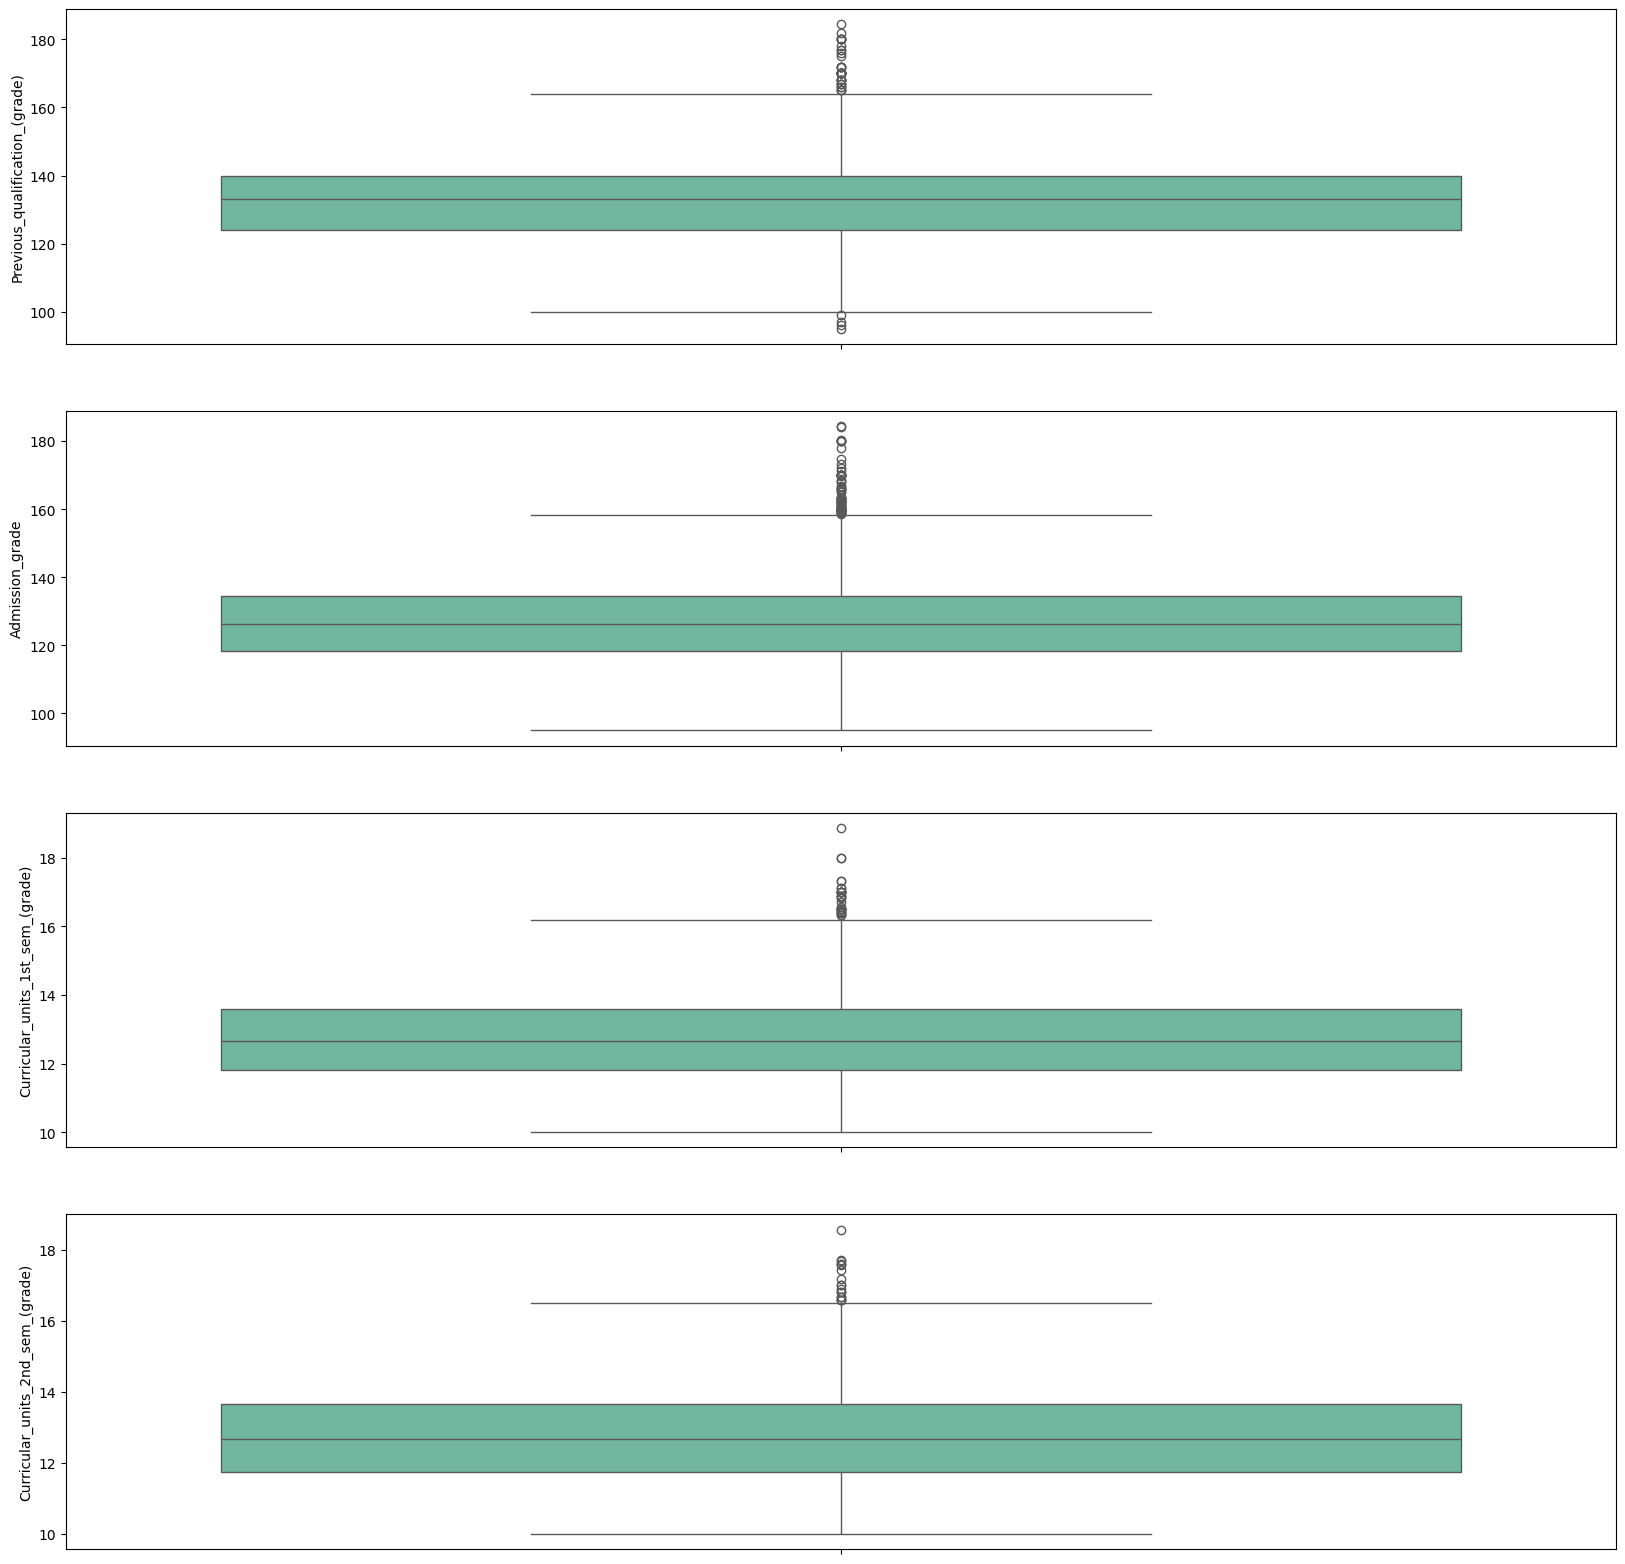

In [32]:
## Hiển thị biểu đồ hộp sau khi xử lý giá trị ngoại lệ.

fig, axs = plt.subplots(4,1, figsize = (20, 20))
plt1 = sns.boxplot(data['Previous_qualification_(grade)'], ax = axs[0], palette = 'BuGn')
plt1 = sns.boxplot(data['Admission_grade'], ax = axs[1], palette = 'BuGn')
plt1 = sns.boxplot(data['Curricular_units_1st_sem_(grade)'], ax = axs[2], palette = 'BuGn')
plt1 = sns.boxplot(data['Curricular_units_2nd_sem_(grade)'], ax = axs[3], palette = 'BuGn')

plt.show()

### Feature Selection bằng Kiểm định Chi-bình phương (Chi-Square Test)

Vì chúng ta có 29 dữ liệu rời rạc (phân loại), nên chúng ta cần thực hiện kiểm định giả thuyết để hiểu xem có mối quan hệ nào giữa biến phụ thuộc và biến độc lập hay không, sau đó chúng ta có thể phân tích loại mối quan hệ đó bằng đồ thị.
Hãy thực hiện kiểm định chi-square để hiểu mối quan hệ giữa biến Target và biến độc lập. 

In [33]:
from sklearn.feature_selection import chi2

In [34]:
# Chia df dataset biến đầu vào và biến target 

X = data[['Curricular_units_2nd_sem_(enrolled)',
 'Scholarship_holder',
 'Application_order',
 'Curricular_units_1st_sem_(evaluations)',
 'Application_mode',
 'Course',
 'Nacionality',
 'Curricular_units_1st_sem_(without_evaluations)',
 'International',
 'Curricular_units_2nd_sem_(without_evaluations)',
 'Age_at_enrollment',
 'Curricular_units_1st_sem_(credited)',
 'Curricular_units_2nd_sem_(credited)',
 'Debtor',
 'Daytime/evening_attendance\t',
 'Marital_status',
 'Previous_qualification',
 "Mother's_qualification",
 'Curricular_units_1st_sem_(approved)',
 "Mother's_occupation",
 'Gender',
 'Displaced',
 'Curricular_units_2nd_sem_(evaluations)',
 'Tuition_fees_up_to_date',
 'Educational_special_needs',
 "Father's_qualification",
 'Curricular_units_2nd_sem_(approved)',
 'Curricular_units_1st_sem_(enrolled)',
 "Father's_occupation"]]

y = data['Target']

In [35]:
# trả về f score and p value 
f_score = chi2(X, y)

In [36]:
p_value = pd.Series(f_score[1],index = X.columns)
# sắp xếp p value series
p_value = p_value.sort_values(ascending = True)
# print p value 
print(p_value)

Application_mode                                   0.000000e+00
Mother's_occupation                                0.000000e+00
Father's_occupation                               1.315731e-272
Curricular_units_2nd_sem_(approved)               1.597835e-148
Curricular_units_1st_sem_(approved)                6.108383e-92
Previous_qualification                             1.106835e-78
Age_at_enrollment                                  2.193555e-55
Curricular_units_2nd_sem_(evaluations)             5.509562e-53
Curricular_units_1st_sem_(evaluations)             3.685394e-47
Debtor                                             8.448138e-45
Course                                             9.805967e-41
Curricular_units_1st_sem_(credited)                1.879439e-40
Scholarship_holder                                 2.106448e-37
Mother's_qualification                             4.613949e-37
Curricular_units_2nd_sem_(credited)                4.435544e-33
Gender                                  

#### **Theo kiểm định Chi-square (Kiểm định tính độc lập)**

1. Giả thuyết null -> Các đặc trưng độc lập với nhau.

2. Giả thuyết thay thế -> Các đặc trưng phụ thuộc vào nhau.

* Nếu giá trị p ≥ 0,05, chúng ta không bác bỏ giả thuyết null, có nghĩa là không có mối quan hệ giữa biến target và các đặc trưng phân loại đầu vào.

* Nếu giá trị p < 0,05, chúng ta có thể bác bỏ giả thuyết null, có nghĩa là các biến target phụ thuộc vào biến phân loại đầu vào.

In [37]:
i_cols=[]
significance_level = 0.05
for i in p_value.index:
    if p_value[i] <= significance_level: 
        print(i,'    :- Reject NULL HYPOTHESIS') 
    else: 
        print(i,'   :-ACCEPT NULL HYPOTHESIS')
        i_cols.append(i)

Application_mode     :- Reject NULL HYPOTHESIS
Mother's_occupation     :- Reject NULL HYPOTHESIS
Father's_occupation     :- Reject NULL HYPOTHESIS
Curricular_units_2nd_sem_(approved)     :- Reject NULL HYPOTHESIS
Curricular_units_1st_sem_(approved)     :- Reject NULL HYPOTHESIS
Previous_qualification     :- Reject NULL HYPOTHESIS
Age_at_enrollment     :- Reject NULL HYPOTHESIS
Curricular_units_2nd_sem_(evaluations)     :- Reject NULL HYPOTHESIS
Curricular_units_1st_sem_(evaluations)     :- Reject NULL HYPOTHESIS
Debtor     :- Reject NULL HYPOTHESIS
Course     :- Reject NULL HYPOTHESIS
Curricular_units_1st_sem_(credited)     :- Reject NULL HYPOTHESIS
Scholarship_holder     :- Reject NULL HYPOTHESIS
Mother's_qualification     :- Reject NULL HYPOTHESIS
Curricular_units_2nd_sem_(credited)     :- Reject NULL HYPOTHESIS
Gender     :- Reject NULL HYPOTHESIS
Curricular_units_2nd_sem_(without_evaluations)     :- Reject NULL HYPOTHESIS
Father's_qualification     :- Reject NULL HYPOTHESIS
Tuition

In [38]:
i_cols

['Marital_status',
 'Daytime/evening_attendance\t',
 'Educational_special_needs',
 'International']

Từ kết quả kiểm định chi bình phương, ta có thể thấy chỉ có 4 đặc điểm không có mối liên hệ với biến target, vì vậy ta có thể loại bỏ những đặc điểm đó và phân tích các đặc điểm còn lại.

In [39]:
# dropping 4 cột không tham gia dự đoán
data.drop(labels= i_cols, axis=1, inplace=True) 

In [40]:
data.head()

,Application_mode,Application_order,Course,Previous_qualification,Previous_qualification_(grade),Nacionality,Mother's_qualification,Father's_qualification,Mother's_occupation,Father's_occupation,...,Curricular_units_2nd_sem_(credited),Curricular_units_2nd_sem_(enrolled),Curricular_units_2nd_sem_(evaluations),Curricular_units_2nd_sem_(approved),Curricular_units_2nd_sem_(grade),Curricular_units_2nd_sem_(without_evaluations),Unemployment_rate,Inflation_rate,GDP,Target
1,15,1,9254,1,160.0,1,1,3,3,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
3,17,2,9773,1,122.0,1,38,37,5,3,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,39,1,8014,1,100.0,1,37,38,9,9,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2
5,39,1,9991,19,133.1,1,37,37,9,7,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,2
6,1,1,9500,1,142.0,1,19,38,7,10,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,2


### Giải quyết hiện tượng Đa cộng tuyến bằng PCA - Giảm chiều dữ liệu

*Trong bộ dữ liệu sinh viên, các biến số liên quan đến Học kỳ 1 và Học kỳ 2 (như số tín chỉ đăng ký, số tín chỉ đậu, số lần đánh giá và điểm số) có sự trùng lặp thông tin cực kỳ lớn (gọi là hiện tượng Đa cộng tuyến - Multicollinearity).* 

*PCA sẽ đứng ra làm nhiệm vụ nén không gian từ hơn 30 thuộc tính còn lại sau Chi-Square xuống thành 10 thành phần chính (Principal Components - PCs) độc lập hoàn toàn với nhau về mặt tuyến tính.*

*Giúp mô hình chạy nhanh hơn, triệt tiêu nhiễu đa cộng tuyến và chống hiện tượng quá khớp (Overfitting).*

In [41]:
# Tách biệt ma trận đặc trưng X (đã lọc qua Chi-square) và nhãn mục tiêu y
X_after_chi2 = data.drop('Target', axis=1)
y = data['Target']

In [42]:
# Bản chất: PCA và K-Means tính toán dựa trên phương sai và khoảng cách hình học.
# Do đó, bắt buộc phải đưa dữ liệu về cùng thang đo Z-score (Mean=0, Std=1).
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_after_chi2)

In [43]:
from sklearn.decomposition import PCA

# Khởi tạo PCA nén dữ liệu xuống còn 10 thành phần chính (PCs)
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Tính toán tổng lượng thông tin (phương sai) mà 10 thành phần này giữ lại được
explained_variance = sum(pca.explained_variance_ratio_) * 100
print(f"   => 10 thành phần chính giữ lại được: {explained_variance:.2f}% thông tin gốc.")

   => 10 thành phần chính giữ lại được: 67.37% thông tin gốc.


### Áp dụng thuật toán K-Means để tạo đặc trưng mới (FEATURE ENGINEERING)

In [44]:
from sklearn.cluster import KMeans

# Khởi tạo K-Means gom cụm sinh viên thành 3 nhóm chân dung tự nhiên
# Sử dụng cơ chế khởi tạo thông minh 'k-means++' để tối ưu tâm cụm ban đầu
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

In [45]:
# Nối nhãn cụm vào không gian PCA
import numpy as np

X_final = np.hstack((X_pca, cluster_labels.reshape(-1, 1)))

print(f"\n=> Nghiệm thu cấu trúc ma trận dữ liệu mới sau xử lý nâng cao: {X_final.shape}")


=> Nghiệm thu cấu trúc ma trận dữ liệu mới sau xử lý nâng cao: (3509, 11)


*Bao gồm 4,424 dòng sinh viên và tinh gọn chỉ còn 11 cột đặc trưng tinh túy*

### CHIA TẬP KIỂM THỬ ĐỘC LẬP (TRAIN-TEST SPLIT)

In [46]:
from sklearn.model_selection import train_test_split

# Thực hiện chia tập dữ liệu trên không gian X_final mới
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

In [47]:
# Cân bằng dữ liệu bằng SMOTE trên không gian số liên tục mới
from imblearn.over_sampling import SMOTE

# Áp dụng SMOTE trên tập X_train để xử lý lệch nhãn mà không lo xung đột kiểu dữ liệu
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f" Cấu trúc tập Train sau khi xử lý cân bằng bằng SMOTE: {X_train_res.shape}")

 Cấu trúc tập Train sau khi xử lý cân bằng bằng SMOTE: (5130, 11)


*Sử dụng thuật toán nội suy láng giềng gần nhất để sinh thêm các mẫu sinh viên nhân tạo cho hai nhóm thiểu số (`Dropout` và `Enrolled`), đưa tỷ lệ mẫu của 3 lớp về mức cân bằng 1:1:1 trên tập huấn luyện.*

*Thuật toán hoạt động hoàn hảo trên không gian véc-tơ liên tục của PCA & K-Means mà không lo xung đột kiểu dữ liệu. Việc chỉ áp dụng SMOTE trên tập `X_train` giúp bảo vệ tập `X_test` độc lập, **chống rò rỉ dữ liệu (Data Leakage)** tuyệt đối theo chuẩn công nghiệp.*

## HUẤN LUYỆN ĐA MÔ HÌNH VÀ ĐÁNH GIÁ CHI TIẾT

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

### Mô hình phân Logistic Regression 

In [49]:
# 1. Khởi tạo mô hình Hồi quy Logistic
# - multi_class='multinomial': Cấu hình chuyên biệt cho bài toán phân loại đa lớp (3 nhãn)
# - max_iter=1000: Tăng số vòng lặp tối đa để đảm bảo thuật toán hội tụ (converge) ổn định trên dữ liệu mới
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

# 2. Huấn luyện mô hình trên tập dữ liệu đã qua xử lý nâng cao (SMOTE + PCA + K-Means)
lr_model.fit(X_train_res, y_train_res)

# 3. Tiến hành dự đoán nhãn trên tập kiểm thử độc lập X_test
y_pred_lr = lr_model.predict(X_test)

========= ĐÁNH GIÁ MÔ HÌNH: LOGISTIC REGRESSION =========
Độ chính xác tổng thể (Accuracy Score): 67.38%

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

     Dropout       0.57      0.51      0.54       136
    Enrolled       0.40      0.57      0.47       145
    Graduate       0.87      0.76      0.81       421

    accuracy                           0.67       702
   macro avg       0.61      0.62      0.61       702
weighted avg       0.71      0.67      0.69       702



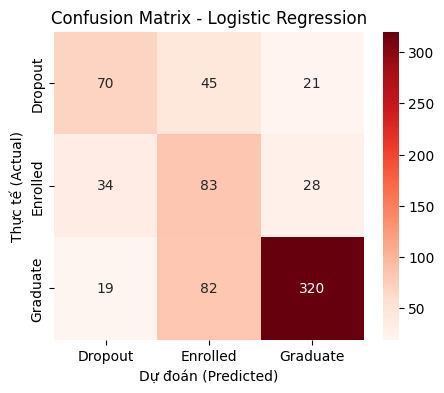

In [50]:
# 4. Xuất chỉ số đánh giá hiệu năng thực nghiệm
print("========= ĐÁNH GIÁ MÔ HÌNH: LOGISTIC REGRESSION =========")
print(f"Độ chính xác tổng thể (Accuracy Score): {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print("\nBáo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_test, y_pred_lr, target_names=['Dropout', 'Enrolled', 'Graduate']))

# 5. Vẽ ma trận nhầm lẫn (Confusion Matrix) để chẩn đoán lỗi sai
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Dropout', 'Enrolled', 'Graduate'],
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.show()

### Mô hình phân loại Naive Bayes

In [51]:
# 1. Khởi tạo mô hình Gaussian Naive Bayes
NB_model = GaussianNB()

# 2. Huấn luyện mô hình trên tập dữ liệu mới đã qua xử lý nâng cao
NB_model.fit(X_train_res, y_train_res)

# 3. Tiến hành dự đoán nhãn trên tập kiểm thử độc lập X_test
y_pred_nb = NB_model.predict(X_test)

========= ĐÁNH GIÁ MÔ HÌNH: GAUSSIAN NAIVE BAYES =========
Độ chính xác tổng thể (Accuracy Score): 61.97%

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

     Dropout       0.43      0.49      0.46       136
    Enrolled       0.36      0.46      0.40       145
    Graduate       0.83      0.72      0.77       421

    accuracy                           0.62       702
   macro avg       0.54      0.56      0.54       702
weighted avg       0.66      0.62      0.63       702



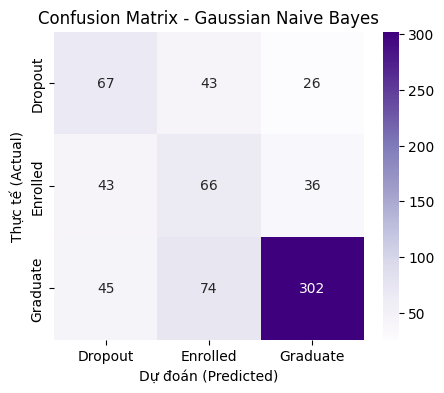

In [52]:
# 4. Xuất chỉ số đánh giá hiệu năng thực nghiệm
print("========= ĐÁNH GIÁ MÔ HÌNH: GAUSSIAN NAIVE BAYES =========")
print(f"Độ chính xác tổng thể (Accuracy Score): {accuracy_score(y_test, y_pred_nb)*100:.2f}%")
print("\nBáo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_test, y_pred_nb, target_names=['Dropout', 'Enrolled', 'Graduate']))

# 5. Vẽ ma trận nhầm lẫn (Confusion Matrix) để chẩn đoán lỗi sai
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Dropout', 'Enrolled', 'Graduate'],
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.show()

### Mô hình phân loại Decision Tree (Cây quyết định)

In [53]:
# 1. Khởi tạo mô hình Cây quyết định với random_state để cố định kết quả
dt_model = DecisionTreeClassifier(random_state=42)

# 2. Huấn luyện mô hình trên tập dữ liệu đã qua xử lý nâng cao (SMOTE + PCA + K-Means)
dt_model.fit(X_train_res, y_train_res)

# 3. Tiến hành dự đoán nhãn trên tập kiểm thử độc lập X_test
y_pred_dt = dt_model.predict(X_test)

========= ĐÁNH GIÁ MÔ HÌNH: DECISION TREE =========
Độ chính xác tổng thể (Accuracy Score): 58.69%

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

     Dropout       0.39      0.50      0.44       136
    Enrolled       0.34      0.41      0.37       145
    Graduate       0.81      0.68      0.74       421

    accuracy                           0.59       702
   macro avg       0.51      0.53      0.51       702
weighted avg       0.63      0.59      0.60       702



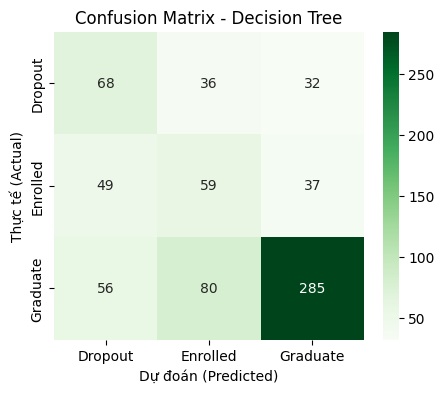

In [54]:
# 4. Xuất chỉ số đánh giá hiệu năng thực nghiệm
print("========= ĐÁNH GIÁ MÔ HÌNH: DECISION TREE =========")
print(f"Độ chính xác tổng thể (Accuracy Score): {accuracy_score(y_test, y_pred_dt)*100:.2f}%")
print("\nBáo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_test, y_pred_dt, target_names=['Dropout', 'Enrolled', 'Graduate']))

# 5. Vẽ ma trận nhầm lẫn (Confusion Matrix) để chẩn đoán lỗi sai
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dropout', 'Enrolled', 'Graduate'],
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.show()

### RANDOM FOREST CLASSIFIER (QUẦN HỢP BAGGING SONG SONG)

In [55]:
# Khởi tạo mô hình gồm 100 cây quyết định độc lập hoạt động song song
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Huấn luyện trên không gian dữ liệu cải tiến (SMOTE + PCA + K-Means)
rf_model.fit(X_train_res, y_train_res)

# Dự đoán trên tập kiểm thử sạch
y_pred_rf = rf_model.predict(X_test)

========= ĐÁNH GIÁ MÔ HÌNH: RANDOM FOREST =========
Độ chính xác tổng thể (Accuracy Score): 68.09%

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

     Dropout       0.53      0.56      0.54       136
    Enrolled       0.41      0.41      0.41       145
    Graduate       0.83      0.81      0.82       421

    accuracy                           0.68       702
   macro avg       0.59      0.59      0.59       702
weighted avg       0.68      0.68      0.68       702



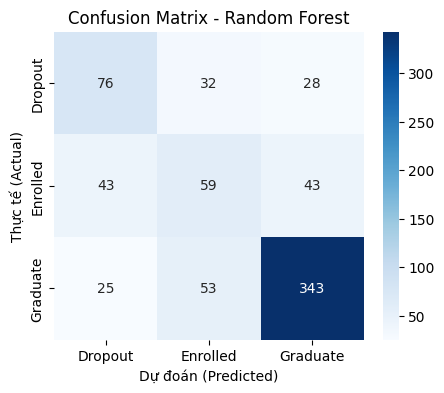

In [56]:
print("========= ĐÁNH GIÁ MÔ HÌNH: RANDOM FOREST =========")
print(f"Độ chính xác tổng thể (Accuracy Score): {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print("\nBáo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_test, y_pred_rf, target_names=['Dropout', 'Enrolled', 'Graduate']))

# Vẽ ma trận nhầm lẫn
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dropout', 'Enrolled', 'Graduate'],
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.show()

### XGBOOST CLASSIFIER (GRADIENT BOOSTING TỐI ƯU)

In [57]:
# Khởi tạo mô hình XGBoost cho bài toán phân loại đa lớp
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='mlogloss')

# Huấn luyện mô hình
xgb_model.fit(X_train_res, y_train_res)

# Dự đoán
y_pred_xgb = xgb_model.predict(X_test)

========= ĐÁNH GIÁ MÔ HÌNH: XGBOOST =========
Độ chính xác tổng thể (Accuracy Score): 68.80%

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

     Dropout       0.55      0.57      0.56       136
    Enrolled       0.42      0.48      0.45       145
    Graduate       0.85      0.80      0.82       421

    accuracy                           0.69       702
   macro avg       0.61      0.62      0.61       702
weighted avg       0.70      0.69      0.69       702



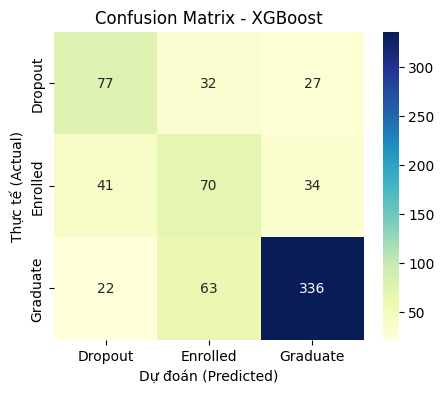

In [58]:
print("========= ĐÁNH GIÁ MÔ HÌNH: XGBOOST =========")
print(f"Độ chính xác tổng thể (Accuracy Score): {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print("\nBáo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_test, y_pred_xgb, target_names=['Dropout', 'Enrolled', 'Graduate']))

# Vẽ ma trận nhầm lẫn
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Dropout', 'Enrolled', 'Graduate'],
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.show()

## LIGHTGBM CLASSIFIER (BOOSTING PHÂN NHÁNH LÁ)

In [59]:
#Khởi tạo mô hình LightGBM, tắt thông báo verbose nhiễu hệ thống
lgb_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)

# Huấn luyện mô hình
lgb_model.fit(X_train_res, y_train_res)

# Dự đoán
y_pred_lgb = lgb_model.predict(X_test)

========= ĐÁNH GIÁ MÔ HÌNH: LIGHTGBM =========
Độ chính xác tổng thể (Accuracy Score): 67.52%

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

     Dropout       0.55      0.57      0.56       136
    Enrolled       0.41      0.48      0.44       145
    Graduate       0.83      0.78      0.80       421

    accuracy                           0.68       702
   macro avg       0.60      0.61      0.60       702
weighted avg       0.69      0.68      0.68       702



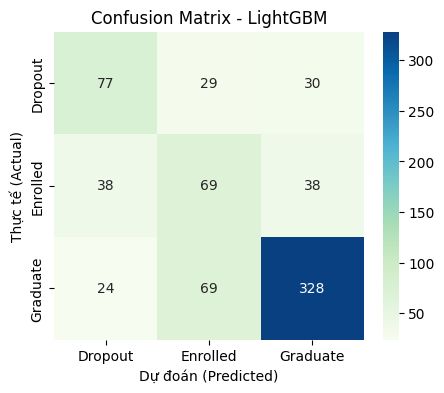

In [60]:
print("========= ĐÁNH GIÁ MÔ HÌNH: LIGHTGBM =========")
print(f"Độ chính xác tổng thể (Accuracy Score): {accuracy_score(y_test, y_pred_lgb)*100:.2f}%")
print("\nBáo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_test, y_pred_lgb, target_names=['Dropout', 'Enrolled', 'Graduate']))

# Vẽ ma trận nhầm lẫn
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='GnBu',
            xticklabels=['Dropout', 'Enrolled', 'Graduate'],
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Confusion Matrix - LightGBM')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.show()

## CATBOOST CLASSIFIER (BOOSTING ĐỐI XỨNG TỐI TÂN)

In [61]:
from catboost import Pool, CatBoostClassifier, cv

# Khởi tạo mô hình CatBoost, tắt thông báo log lặp để output sạch sẽ
cat_model = CatBoostClassifier(iterations=150, learning_rate=0.1, random_state=42, verbose=0)

# Huấn luyện mô hình
cat_model.fit(X_train_res, y_train_res)

# Dự đoán
y_pred_cat = cat_model.predict(X_test)

========= ĐÁNH GIÁ MÔ HÌNH: CATBOOST =========
Độ chính xác tổng thể (Accuracy Score): 66.52%

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

     Dropout       0.56      0.57      0.56       136
    Enrolled       0.39      0.46      0.42       145
    Graduate       0.83      0.77      0.80       421

    accuracy                           0.67       702
   macro avg       0.59      0.60      0.59       702
weighted avg       0.68      0.67      0.67       702



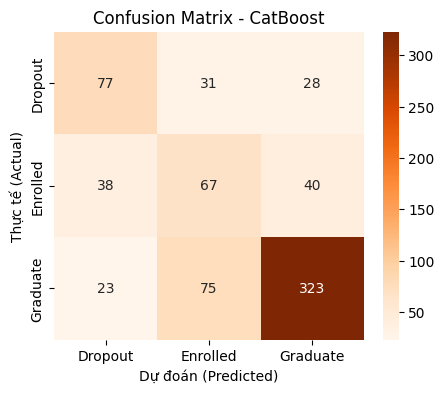

In [62]:
print("========= ĐÁNH GIÁ MÔ HÌNH: CATBOOST =========")
print(f"Độ chính xác tổng thể (Accuracy Score): {accuracy_score(y_test, y_pred_cat)*100:.2f}%")
print("\nBáo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_test, y_pred_cat, target_names=['Dropout', 'Enrolled', 'Graduate']))

# Vẽ ma trận nhầm lẫn
cm_cat = confusion_matrix(y_test, y_pred_cat)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Dropout', 'Enrolled', 'Graduate'],
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Confusion Matrix - CatBoost')
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.show()

## TỔNG HỢP VÀ TRỰC QUAN HÓA BẢNG SO SÁNH HIỆU NĂNG 7 MÔ HÌNH

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

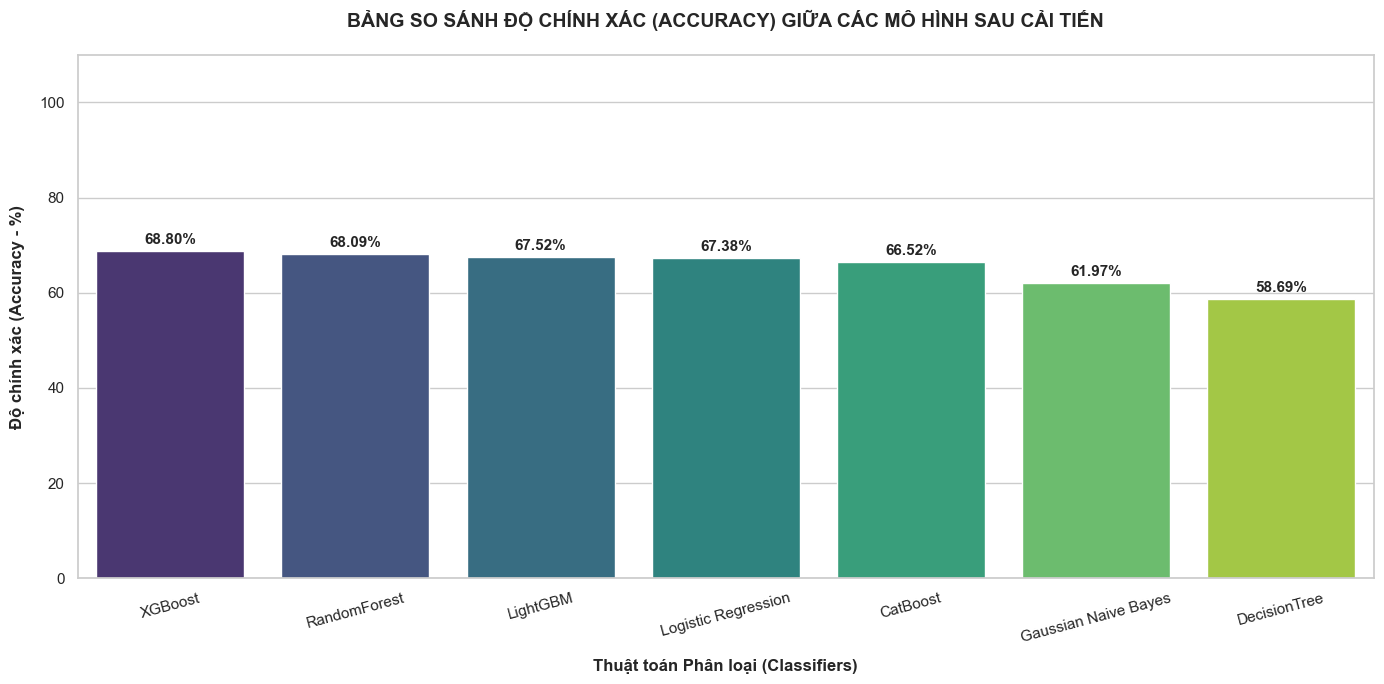

In [64]:
# 1. Khởi tạo DataFrame tổng hợp điểm số dựa trên tên các biến dự đoán mới của bạn
Models_Updated = pd.DataFrame({
    'Classifiers': [
        'Logistic Regression', 
        'Gaussian Naive Bayes', 
        'DecisionTree', 
        'RandomForest', 
        'XGBoost', 
        'LightGBM', 
        'CatBoost'
    ], 
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr) * 100,
        accuracy_score(y_test, y_pred_nb) * 100,
        accuracy_score(y_test, y_pred_dt) * 100,
        accuracy_score(y_test, y_pred_rf) * 100,
        accuracy_score(y_test, y_pred_xgb) * 100,
        accuracy_score(y_test, y_pred_lgb) * 100,
        accuracy_score(y_test, y_pred_cat) * 100
    ]
})
# 2. Sắp xếp lại thứ tự điểm số từ cao xuống thấp giúp biểu đồ có tính phân cấp rõ ràng
Models_Updated = Models_Updated.sort_values(by='Accuracy', ascending=False)

# 3. Cấu hình giao diện biểu đồ nâng cao
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid") # Thay thế cấu hình sns.set() cũ để có lưới mờ sang trọng hơn

# Lưu ý kỹ thuật: Sửa lỗi Seaborn đời mới bằng cách chỉ định rõ tham số x, y và data
ax = sns.barplot(x='Classifiers', y='Accuracy', data=Models_Updated, palette='viridis')

# 4. Sử dụng vòng lặp tự động điền nhãn số liệu (%) lên đỉnh mỗi cột
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', 
                fontweight='bold', 
                fontsize=11)
# 5. Thiết lập tiêu đề và nhãn các trục tọa độ
plt.title('BẢNG SO SÁNH ĐỘ CHÍNH XÁC (ACCURACY) GIỮA CÁC MÔ HÌNH SAU CẢI TIẾN', fontsize=14, fontweight='bold', pad=20)
plt.ylim(0, 110) # Tới 110% để chừa không gian trống phía trên cho nhãn số liệu không bị đè vỡ
plt.xlabel('Thuật toán Phân loại (Classifiers)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Độ chính xác (Accuracy - %)', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=15, fontsize=11)
plt.tight_layout()

# 6. Xuất đồ thị trực quan
plt.show()

## Đánh giá kết quả các mô hình

- **XGBoost** đạt kết quả cao nhất vì mô hình có khả năng học tốt các mối quan hệ phi tuyến và tối ưu lỗi qua nhiều vòng boosting, phù hợp với dữ liệu có pattern phức tạp.

- **Random Forest** cho kết quả rất tốt nhờ sử dụng nhiều cây quyết định để giảm overfitting và tăng khả năng tổng quát hóa dữ liệu.

- **LightGBM** có hiệu suất gần tương đương XGBoost do cũng thuộc nhóm boosting, tuy nhiên mô hình thường phát huy mạnh hơn trên tập dữ liệu lớn.

- **Logistic Regression** vẫn đạt accuracy khá cao chứng tỏ dữ liệu vẫn tồn tại mối quan hệ tuyến tính giữa các đặc trưng và nhãn phân loại.

- **CatBoost** chưa nổi bật vì dữ liệu có thể không chứa nhiều thuộc tính categorical hoặc đã được xử lý trước nên lợi thế của CatBoost chưa được thể hiện rõ.

- **Gaussian Naive Bayes** có kết quả thấp hơn do mô hình giả định các đặc trưng độc lập với nhau và tuân theo phân phối Gaussian, điều này thường không đúng hoàn toàn trong thực tế.

- **Decision Tree** cho kết quả thấp nhất vì chỉ sử dụng một cây quyết định nên dễ bị overfitting và khả năng tổng quát hóa kém hơn các mô hình ensemble.

# Tổng kết

Bài toán "Dự đoán sinh viên bỏ học và kết quả học tập" được định nghĩa là bài toán Học máy giám sát (Supervised Learning), cụ thể là Phân loại đa lớp (Multi-class Classification) với 3 nhãn đầu ra mục tiêu: Dropout (Bỏ học), Enrolled (Đang theo học), Graduate (Tốt nghiệp).

Để giải quyết trọn vẹn bài toán này từ dữ liệu thô ban đầu, hệ thống đã thiết lập một chuỗi xử lý khép kín (End-to-End Pipeline) gồm 5 tầng logic:

[Dữ liệu Thô] ➔ [Lọc Thô Chi-Square] ➔ [Nén Khối PCA] ➔ [Gom Cụm K-Means] ➔ [Cân Bằng SMOTE] ➔ [Phân Loại Đa Mô Hình]

In [66]:
import joblib

# 1. Lưu các bộ tiền xử lý và kỹ nghệ đặc trưng
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')
joblib.dump(kmeans, 'kmeans.pkl')

# 2. Lưu mô hình XGBoost tốt nhất
joblib.dump(xgb_model, 'best_student_dropout_xgb.pkl')

print("Hệ thống đã đóng gói thành công 4 file pkl!")

Hệ thống đã đóng gói thành công 4 file pkl!


In [73]:
# =====================================================================
# XUẤT FILE DEMO GIỮ NGUYÊN CỘT TARGET DẠNG CHỮ ĐỂ ĐỐI CHIẾU
# =====================================================================

# 1. Tự động lấy mẫu thực tế dựa vào số hoặc chữ hiện tại trong bộ nhớ
if data['Target'].dtype == 'object':
    dropout_sample = data[data['Target'] == 'Dropout'].head(1).copy()
    enrolled_sample = data[data['Target'] == 'Enrolled'].head(1).copy()
    graduate_sample = data[data['Target'] == 'Graduate'].head(1).copy()
else:
    dropout_sample = data[data['Target'] == 0].head(1).copy()
    enrolled_sample = data[data['Target'] == 1].head(1).copy()
    graduate_sample = data[data['Target'] == 2].head(1).copy()

# Gộp 3 dòng thực tế lại
demo_profiles = pd.concat([dropout_sample, enrolled_sample, graduate_sample])

# 2. Ánh xạ (Map) ngược từ số về lại chữ để lưu vào CSV cho trực quan
mapping = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
demo_profiles['Target'] = demo_profiles['Target'].replace(mapping)

# 3. Print hiển thị bảng dữ liệu ngay tại Notebook để Phong kiểm tra
print(" BẢNG DỮ LIỆU ĐỐI CHIẾU THỰC TẾ (INSPECT DATA):")
display(demo_profiles[['Target', 'Tuition_fees_up_to_date', 'Age_at_enrollment', 'Curricular_units_2nd_sem_(approved)', 'Curricular_units_2nd_sem_(grade)']])

# 4. Xuất file CSV sạch sẽ chứa cả cột Target dạng chữ
demo_profiles.to_csv('demo_profiles.csv', index=False)

 BẢNG DỮ LIỆU ĐỐI CHIẾU THỰC TẾ (INSPECT DATA):


,Target,Tuition_fees_up_to_date,Age_at_enrollment,Curricular_units_2nd_sem_(approved),Curricular_units_2nd_sem_(grade)
9,Dropout,0,18,2,13.500000
16,Enrolled,1,18,2,11.000000
1,Graduate,0,19,6,13.666667
